# Panel Integrado de Variables Macroeconómicas

---
## 0. Imports y Configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
from pathlib import Path

from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.filters.hp_filter import hpfilter
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

RUTA_BASE = Path(r'C:\Users\marco\PycharmProjects\TFM_Marcos\Datasets')
FREQ = 'QS'   # Principio del trimestre

COLOR_PRINCIPAL = '#5E35B1'
COLORES = ['#5E35B1', '#00897B', '#FF7043', '#FFC107', '#1565C0', '#AD1457']

EVENTOS = {
    '1986-01-01': 'Entrada UE',
    '1999-01-01': 'Euro',
    '2008-09-01': 'Crisis\nfinanciera',
    '2012-01-01': 'Crisis\ndeuda',
    '2020-03-01': 'COVID-19',
}

In [2]:
# ============================================================
# CONFIGURACIÓN DE TODOS LOS DATASETS
# ============================================================

# lag_pub = 0, la información es conocida a tiempo real; lag_pub = 1, la información se conoce una vez ha terminado el trimestre
TODOS_DATASETS = {

    'parados': {
        'archivo': 'parados_sexo_edad.csv', 'frecuencia': 'trimestral', 'agg': None,
        'columnas': None,
        'lag_pub': 1,
    },

    'poblacion': {
        'archivo': 'poblacion_relacion_actividad_economica_sexo_edad.csv', 'frecuencia': 'trimestral', 'agg': None,
        'columnas': None,
        'lag_pub': 1,
    },

    'ocupados': {
        'archivo': 'ocupados_situacion_profesional_sexo.csv', 'frecuencia': 'trimestral', 'agg': None,
        'columnas': None,
        'lag_pub': 1,
    },

    'inactivos': {
        'archivo': 'inactivos_situacion_inactividad_sexo.csv', 'frecuencia': 'trimestral', 'agg': None,
        'columnas': None,
        'lag_pub': 1,
    },

    'pib_demanda': {
        'archivo': 'pib_demanda_constantes_2025_1970_2026.csv', 'frecuencia': 'trimestral', 'agg': None,
        'columnas': None,
        'lag_pub': 1,
    },

    'pib_demanda_corrientes': {
        'archivo': 'pib_demanda_corrientes_1970_2026.csv', 'frecuencia': 'trimestral', 'agg': None,
        'columnas': None,
        'lag_pub': 1,
    },

    'pib_oferta': {
        'archivo': 'pib_oferta_constantes_2025_1970_2026.csv', 'frecuencia': 'trimestral', 'agg': None,
        'columnas': None,
        'lag_pub': 1,
    },

    'ipc': {
        'archivo': 'indice_precios_consumo_IPC_diferentes_bases_trimestral.csv', 'frecuencia': 'trimestral', 'agg': None,
        'columnas': None,
        'lag_pub': 0,
    },

    'petroleo': {
        'archivo': 'petroleo_precio_diario_barril_1946_2026_trimestral.csv', 'frecuencia': 'trimestral', 'agg': None,
        'columnas': None,
        'lag_pub': 0,
    },

    'tipos_interes': {
        'archivo': 'interes_legal_interes_demora_tributaria_trimestral.csv', 'frecuencia': 'trimestral', 'agg': None,
        'columnas': None,
        'lag_pub': 0,
    },

    'tipo_cambio': {
        'archivo': 'tipo_de_cambio_euro_historico_trimestral.csv', 'frecuencia': 'trimestral', 'agg': None,
        'columnas': None,
        'lag_pub': 0,
    },

    'banca_activo': {
        'archivo': 'ed_activo_historico_1962_2026_trimestral.csv', 'frecuencia': 'trimestral', 'agg': None,
        'columnas': None,
        'lag_pub': 1,
    },

    'banca_pasivo': {
        'archivo': 'ed_pasivo_historico_1962_2026_trimestral.csv', 'frecuencia': 'trimestral', 'agg': None,
        'columnas': None,
        'lag_pub': 1,
    },

    'ipri': {
        'archivo': 'indice_precios_industriales_IPRI_bases_2021_2025_trimestral.csv', 'frecuencia': 'trimestral', 'agg': None,
        'columnas': None,
        'lag_pub': 0,
    },

    'ipi': {
        'archivo': 'ipi_constantes_2025_1975_2026_trimestral.csv', 'frecuencia': 'trimestral', 'agg': None,
        'columnas': None,
        'lag_pub': 1,
    },
}

---
## 1. Carga de Todos los Datasets

In [3]:
def cargar_dataset(nombre, config, ruta_base=RUTA_BASE, freq=FREQ):
    ruta = ruta_base / config['archivo']
    df = pd.read_csv(ruta, decimal=',')
    df['fecha'] = pd.to_datetime(df['fecha'])

    cols_meta = ['fecha', 'año', 'trimestre', 'periodo', 'mes']
    cols = config.get('columnas')
    if cols is None:
        cols = [c for c in df.columns if c not in cols_meta]
        cols = [c for c in cols if pd.to_numeric(df[c], errors='coerce').notna().any()]

    cols_disponibles = [c for c in cols if c in df.columns]
    if not cols_disponibles:
        print(f'  {nombre}: sin columnas numéricas — OMITIDO')
        return None

    df = df[['fecha'] + cols_disponibles].copy()
    for c in cols_disponibles:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    if config['frecuencia'] in ('mensual', 'diaria') and config['agg']:
        df = df.set_index('fecha').resample(freq).agg(config['agg']).reset_index()

    rename = {c: f'{nombre}__{c}' for c in cols_disponibles}
    df = df.rename(columns=rename).set_index('fecha')

    return df


print('DATASETS')
print('=' * 65)

dfs = {}
resumen_carga = []

for nombre, config in TODOS_DATASETS.items():
    df_cargado = cargar_dataset(nombre, config)
    if df_cargado is not None:
        dfs[nombre] = df_cargado
        resumen_carga.append({
            'dataset': nombre,
            'columnas': len(df_cargado.columns),
            'desde': df_cargado.index.min().date(),
            'hasta': df_cargado.index.max().date(),
            'n_obs': len(df_cargado),
            'lag_pub': config['lag_pub'],
        })
        print(f'  {nombre}: {len(df_cargado.columns)} cols, '
              f'{df_cargado.index.min().date()} — {df_cargado.index.max().date()}')

print('=' * 65)
print(f'Datasets cargados: {len(dfs)} de {len(TODOS_DATASETS)}')

df_resumen_carga = pd.DataFrame(resumen_carga)
display(df_resumen_carga)

DATASETS
  parados: 34 cols, 1976-07-01 — 2025-10-01
  poblacion: 96 cols, 1976-07-01 — 2025-10-01
  ocupados: 29 cols, 1976-07-01 — 2025-10-01
  inactivos: 23 cols, 1976-07-01 — 2025-10-01
  pib_demanda: 18 cols, 1974-07-01 — 2025-10-01
  pib_demanda_corrientes: 13 cols, 1974-07-01 — 2025-10-01
  pib_oferta: 6 cols, 1974-07-01 — 2025-10-01
  ipc: 7 cols, 1974-07-01 — 2025-10-01
  petroleo: 3 cols, 1974-07-01 — 2025-10-01
  tipos_interes: 4 cols, 1974-07-01 — 2025-10-01
  tipo_cambio: 11 cols, 1974-07-01 — 2025-10-01
  banca_activo: 13 cols, 1974-07-01 — 2025-10-01
  banca_pasivo: 15 cols, 1974-07-01 — 2025-10-01
  ipri: 23 cols, 1975-01-01 — 2025-10-01
  ipi: 8 cols, 1975-01-01 — 2025-10-01
Datasets cargados: 15 de 15


,dataset,columnas,desde,hasta,n_obs,lag_pub
0,parados,34,1976-07-01,2025-10-01,198,1
1,poblacion,96,1976-07-01,2025-10-01,198,1
2,ocupados,29,1976-07-01,2025-10-01,198,1
3,inactivos,23,1976-07-01,2025-10-01,198,1
4,pib_demanda,18,1974-07-01,2025-10-01,206,1
5,pib_demanda_corrientes,13,1974-07-01,2025-10-01,206,1
6,pib_oferta,6,1974-07-01,2025-10-01,206,1
7,ipc,7,1974-07-01,2025-10-01,206,0
8,petroleo,3,1974-07-01,2025-10-01,206,0
9,tipos_interes,4,1974-07-01,2025-10-01,206,0


---
## 2. Cobertura Temporal del Panel

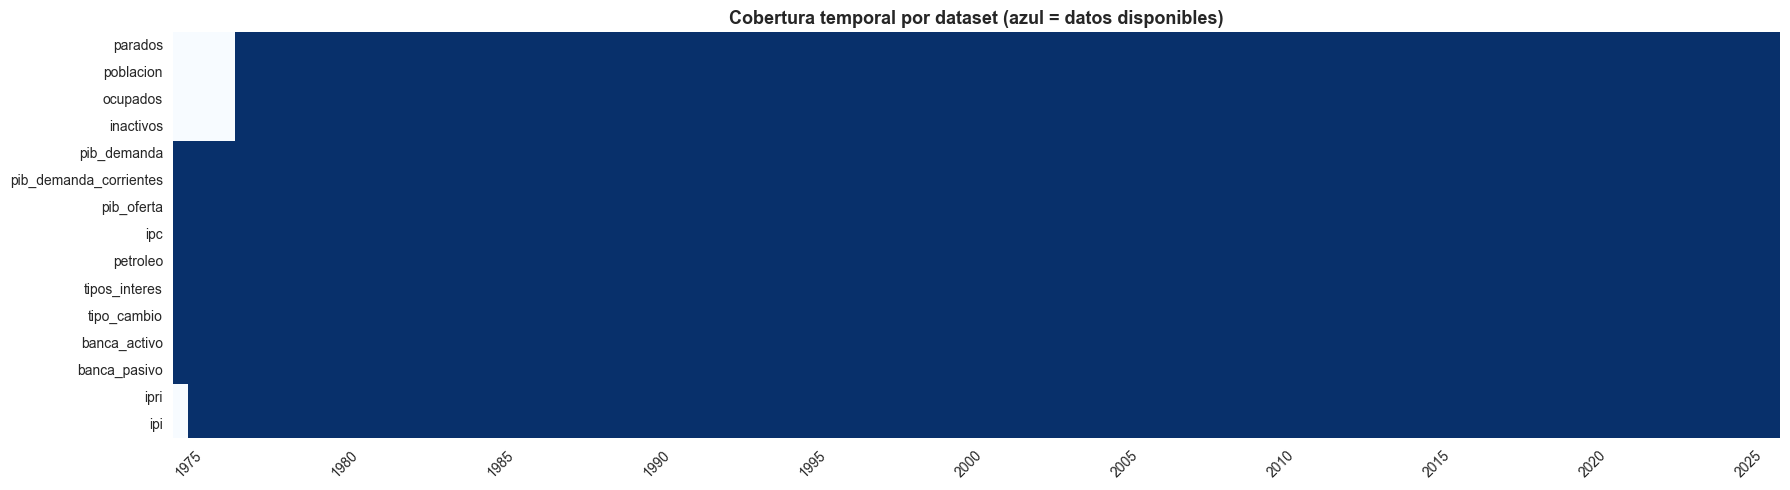

Rango de cada dataset (inicio → fin):
  parados                   1976-07-01 — 2025-10-01
  poblacion                 1976-07-01 — 2025-10-01
  ocupados                  1976-07-01 — 2025-10-01
  inactivos                 1976-07-01 — 2025-10-01
  pib_demanda               1974-07-01 — 2025-10-01 (recorte al inicio)
  pib_demanda_corrientes    1974-07-01 — 2025-10-01 (recorte al inicio)
  pib_oferta                1974-07-01 — 2025-10-01 (recorte al inicio)
  ipc                       1974-07-01 — 2025-10-01 (recorte al inicio)
  petroleo                  1974-07-01 — 2025-10-01 (recorte al inicio)
  tipos_interes             1974-07-01 — 2025-10-01 (recorte al inicio)
  tipo_cambio               1974-07-01 — 2025-10-01 (recorte al inicio)
  banca_activo              1974-07-01 — 2025-10-01 (recorte al inicio)
  banca_pasivo              1974-07-01 — 2025-10-01 (recorte al inicio)
  ipri                      1975-01-01 — 2025-10-01 (recorte al inicio)
  ipi                       1975-0

In [4]:
# Calcular rango global para el heatmap
fecha_global_min = min(df.index.min() for df in dfs.values())
fecha_global_max = max(df.index.max() for df in dfs.values())
indice_global = pd.date_range(start=fecha_global_min, end=fecha_global_max, freq=FREQ)

# Matriz de disponibilidad: 1 si el dataset tiene datos en ese trimestre
matriz_cob = pd.DataFrame(0, index=list(dfs.keys()), columns=indice_global)
for nombre, df in dfs.items():
    for fecha in df.index:
        if fecha in indice_global:
            matriz_cob.loc[nombre, fecha] = 1

# Heatmap
# Muestrear fechas para que el gráfico no sea demasiado ancho
fechas_etiqueta = pd.date_range(start=fecha_global_min, end=fecha_global_max, freq='5YS')

fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(matriz_cob, ax=ax, cbar=False, cmap='Blues',
            linewidths=0.0, linecolor='white')

# Eje X: solo mostrar cada 5 años
xticks_pos = [list(indice_global).index(f) for f in fechas_etiqueta if f in indice_global]
ax.set_xticks(xticks_pos)
ax.set_xticklabels([f.year for f in fechas_etiqueta if f in indice_global], rotation=45)
ax.set_title('Cobertura temporal por dataset (azul = datos disponibles)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Rango de intersección estricta
fecha_interseccion_min = max(df.index.min() for df in dfs.values())
fecha_interseccion_max = min(df.index.max() for df in dfs.values())

print(f'Rango de cada dataset (inicio → fin):')
for nombre, df in dfs.items():
    perdida_inicio = (df.index.min() < fecha_interseccion_min)
    perdida_fin    = (df.index.max() > fecha_interseccion_max)
    print(f'  {nombre:<25} {df.index.min().date()} — {df.index.max().date()}'
          f'{" (recorte al inicio)" if perdida_inicio else ""}'
          f'{" (recorte al final)" if perdida_fin else ""}')

print(f'\nInterseccion estricta: {fecha_interseccion_min.date()} — {fecha_interseccion_max.date()}')

---
## 3. Merge e Intersección Temporal

In [5]:
# Merge de todos los datasets
panel = list(dfs.values())[0].copy()
for df in list(dfs.values())[1:]:
    panel = panel.join(df, how='outer')

print(f'Panel tras merge: {panel.shape[1]} columnas')

# Deduplicar variables base presentes en varios datasets.
# Vamos a usar el dataset de Población como fuente canónica de las variables compartidas
from collections import defaultdict
base_to_cols = defaultdict(list)
for c in panel.columns:
    if '__' in c:
        ds, base = c.split('__', 1)
        base_to_cols[base].append((ds, c))

cols_to_drop = []
for base, entries in base_to_cols.items():
    if len(entries) > 1:
        datasets = [e[0] for e in entries]
        if 'poblacion' in datasets:
            for ds, full_col in entries:
                if ds != 'poblacion':
                    cols_to_drop.append(full_col)

if cols_to_drop:
    panel = panel.drop(columns=cols_to_drop)
    print(f'Columnas duplicadas eliminadas (copias en datasets especializados): {len(cols_to_drop)}')
    for c in sorted(cols_to_drop):
        print(f'  - {c}')

# Restricción a la intersección estricta
panel = panel.loc[fecha_interseccion_min:fecha_interseccion_max]

# Solo forward-fill para NaN internos (no en extremos donde se hayan podido crear por aplicar lag)
panel = panel.ffill()

print(f'\nPanel base:')
print(f'  Shape:          {panel.shape}')
print(f'  Rango:          {panel.index.min().date()} — {panel.index.max().date()}')
print(f'  Observaciones:  {len(panel)} trimestres')
print(f'  Variables:      {panel.shape[1]}')

nulos_residuales = panel.isnull().sum().sum()
print(f'  NaN residuales: {nulos_residuales}')

# Guardar panel base
panel.to_csv(RUTA_BASE / 'panel_base.csv')
print('\npanel_base.csv guardado')

Panel tras merge: 303 columnas
Columnas duplicadas eliminadas (copias en datasets especializados): 27
  - inactivos__inactivos_ambos_sexos_total
  - inactivos__inactivos_hombres_total
  - inactivos__inactivos_mujeres_total
  - inactivos__tasa_inactividad_ambos_sexos_total
  - ocupados__ocupados_ambos_sexos_total
  - ocupados__ocupados_hombres_total
  - ocupados__ocupados_mujeres_total
  - ocupados__tasa_empleo_ambos_sexos_total
  - parados__brecha_genero_paro
  - parados__parados_ambos_sexos_25_o_mas
  - parados__parados_ambos_sexos_menos_de_25
  - parados__parados_ambos_sexos_total
  - parados__parados_hombres_25_o_mas
  - parados__parados_hombres_menos_de_25
  - parados__parados_hombres_total
  - parados__parados_mujeres_25_o_mas
  - parados__parados_mujeres_menos_de_25
  - parados__parados_mujeres_total
  - parados__tasa_paro_ambos_sexos_25_o_mas
  - parados__tasa_paro_ambos_sexos_menos_de_25
  - parados__tasa_paro_ambos_sexos_total
  - parados__tasa_paro_hombres_25_o_mas
  - parado

---
## 4. Ingeniería de Variables Inter-Dataset

In [6]:
# Acceso rápido a columnas (con prefijo de dataset)

def col(dataset, columna):
    return f'{dataset}__{columna}'


eng = pd.DataFrame(index=panel.index)

# ── 4.1 MERCADO LABORAL ─────────────────────────────────────────────────────
# Las tasas de paro, empleo, actividad y sus derivadas ya vienen cargadas de los CSVs.
# Se calcula variacion_paro_yoy (variación interanual de tasa_paro), necesaria para la Ley de Okun que no se encontraba en el csv de Población.

COL_TASA_PARO = col('parados', 'tasa_paro_ambos_sexos_total')
if COL_TASA_PARO not in panel.columns:
    COL_TASA_PARO = col('poblacion', 'tasa_paro_ambos_sexos_total')

if COL_TASA_PARO in panel.columns:
    eng['tasa_paro_total'] = panel[COL_TASA_PARO]
    eng['variacion_paro_yoy'] = panel[COL_TASA_PARO].diff(4)
    print(f'tasa_paro_total y variacion_paro_yoy desde {COL_TASA_PARO}')
else:
    print('ALERTA tasa_paro_ambos_sexos_total no encontrada en el panel')

tasa_paro_total y variacion_paro_yoy desde poblacion__tasa_paro_ambos_sexos_total


### 4.1b Clasificación EPA por la regla de 3 niveles

El bloque del mercado laboral (EPA) está ligado al target por identidad contable, por lo que se clasifica en tres niveles según sus características:

- **Nivel 1 (endógenas, solo VAR/VECM):** tasas agregadas y conteos totales, tautológicos con el target.
- **Nivel 2 (exógenas con lag):** composición estructural (shares y ratios), entran como candidatas.
- **Nivel 3 (endógenas):** derivadas del propio paro.

Solo el **Nivel 2** alimenta el pipeline de regresores exógenos; Nivel 1 y Nivel 3 se reservan para los sistemas multiecuación (VAR/VECM). Fuente canónica de las tasas: población.

In [7]:
# -- 4.1b CLASIFICACIÓN de las variables procedentes de la EPA --------------------------
#   tasa_actividad/empleo/inactividad = X / poblacion_16+ ;  tasa_paro = parados / activos

# Nivel 1 -- agregados/tasas totales -> ENDÓGENAS (solo VAR/VECM)
EPA_NIVEL1 = {
    'tasa_paro':        col('poblacion', 'tasa_paro_ambos_sexos_total'),    # TARGET
    'tasa_empleo':      col('poblacion', 'tasa_empleo_ambos_sexos_total'),
    'tasa_actividad':   col('poblacion', 'tasa_actividad_ambos_sexos_total'),
    'tasa_inactividad': col('poblacion', 'tasa_inactividad_ambos_sexos_total'),  # =100-actividad
    'parados_total':    col('poblacion', 'parados_ambos_sexos_total'),
    'ocupados_total':   col('poblacion', 'ocupados_ambos_sexos_total'),
    'activos_total':    col('poblacion', 'activos_ambos_sexos_total'),
    'inactivos_total':  col('poblacion', 'inactivos_ambos_sexos_total'),
    'poblacion_16mas':  col('poblacion', 'poblacion_mayor_16_ambos_sexos_total'),
}

# Nivel 2 -- composición estructural -> EXÓGENAS con lag (candidatas a features)
EPA_NIVEL2 = {
    'ratio_asalariados':              col('ocupados',  'ratio_asalariados'),
    'share_empleo_publico':           col('ocupados',  'share_empleo_publico'),
    'tasa_autoempleo':                col('ocupados',  'tasa_autoempleo'),
    'share_empleo_femenino':          col('ocupados',  'share_empleo_femenino'),
    'share_labores_hogar':            col('inactivos', 'share_labores_hogar'),
    'share_pensionistas':             col('inactivos', 'share_pensionistas'),
    'share_estudiantes':              col('inactivos', 'share_estudiantes'),
    'ratio_feminizacion_inactividad': col('inactivos', 'ratio_feminizacion_inactividad'),
    'ratio_dependencia':              col('poblacion', 'ratio_dependencia'),
    'convergencia_actividad':         col('poblacion', 'convergencia_actividad'),
    'brecha_genero_actividad':        col('poblacion', 'brecha_genero_actividad'),
    'brecha_genero_empleo':           col('poblacion', 'brecha_genero_empleo'),
}

# Nivel 3 -- derivadas del propio paro -> ENDÓGENAS (con los agregados, solo VAR/VECM)

EPA_NIVEL3 = {
    'share_paro_juvenil':        col('parados',   'share_paro_juvenil'),
    'ratio_paro_juvenil_adulto': col('poblacion', 'ratio_paro_juvenil_adulto'),
    'brecha_genero_parados':     col('parados',   'brecha_genero_parados'),
    'brecha_genero_paro':        col('poblacion', 'brecha_genero_paro'),
    'ratio_feminizacion_paro':   col('parados',   'ratio_feminizacion_paro'),
    'indice_relativo_paro':      col('parados',   'indice_relativo_paro'),
}

# Verificación de presencia en el panel
for nombre, d in [('Nivel 1 (endógenas)', EPA_NIVEL1),
                  ('Nivel 2 (exógenas)',  EPA_NIVEL2),
                  ('Nivel 3 (endógenas)', EPA_NIVEL3)]:
    faltan = [k for k, v in d.items() if v not in panel.columns]
    print(f'{nombre}: {len(d)} vars' + (f'  FALTAN: {faltan}' if faltan else '  OK'))

# Solo el Nivel 2 entra al pipeline de regresores exógenos .
# Nivel 1 y Nivel 3 quedan reservados para los sistemas multiecuación (VAR/VECM).
for nombre_limpio, panel_col in EPA_NIVEL2.items():
    if panel_col in panel.columns:
        eng[nombre_limpio] = panel[panel_col]

print(f'\nNivel 2 anadido a eng (dataset de "engineered features" como variables candidatas. eng: {len(eng.columns)} columnas')

Nivel 1 (endógenas): 9 vars  OK
Nivel 2 (exógenas): 12 vars  OK
Nivel 3 (endógenas): 6 vars  OK

Nivel 2 anadido a eng (dataset de "engineered features" como variables candidatas. eng: 14 columnas


In [8]:
# ── 4.2 CRECIMIENTO, CICLO Y ESTRUCTURA (PIB) ──────────────────────────────

COL_PIB = col('pib_demanda', 'pib_pm')
COL_PIB_CORRIENTE = col('pib_demanda_corrientes', 'pib_pm')
COL_VAB_CONST = col('pib_oferta', 'vab_construccion')
COL_VAB_SERV  = col('pib_oferta', 'vab_servicios')

if COL_PIB in panel.columns:
    pib = panel[COL_PIB]
    eng['crecimiento_pib_qoq'] = pib.pct_change(1) * 100
    eng['crecimiento_pib_yoy'] = pib.pct_change(4) * 100

    pib_sin_nan = pib.dropna()
    ciclo_hp, _ = hpfilter(pib_sin_nan, lamb=1600)  # hpfilter devuelve (ciclo, tendencia); el ciclo es el output gap
    eng.loc[ciclo_hp.index, 'brecha_output_hp'] = ciclo_hp.values

if all(c in panel.columns for c in [COL_VAB_CONST, COL_PIB]):
    eng['peso_construccion_pib'] = panel[COL_VAB_CONST] / panel[COL_PIB] * 100

if all(c in panel.columns for c in [COL_VAB_SERV, COL_PIB]):
    eng['peso_servicios_pib'] = panel[COL_VAB_SERV] / panel[COL_PIB] * 100

if all(c in panel.columns for c in [COL_PIB_CORRIENTE, COL_PIB]):
    eng['deflactor_pib'] = panel[COL_PIB_CORRIENTE] / panel[COL_PIB] * 100

In [9]:
# ── 4.3 PRECIOS E INFLACION ───────────────────────────────────────────────────
# No quedan variables inter-dataset por calcular en este bloque.

In [10]:
# ── 4.4 VARIABLES FINANCIERAS CRUZADAS ───────────────────────────────────────

COL_INTERES = col('tipos_interes', 'interes_legal')
COL_PETROLEO = col('petroleo', 'usd_barril')
COL_USD = col('tipo_cambio', 'HEUR_USD')
COL_CRED_PRIV = col('banca_activo', 'ed_activo_credito_sector_privado')
COL_IPC25 = col('ipc', 'IPC_2025')
COL_INFLACION = col('ipc', 'inflacion_yoy')

if all(c in panel.columns for c in [COL_INTERES, COL_INFLACION]):
    eng['tipo_interes_real'] = panel[COL_INTERES] - panel[COL_INFLACION]

if all(c in panel.columns for c in [COL_PETROLEO, COL_USD]):
    eng['precio_petroleo_heur'] = panel[COL_PETROLEO] / panel[COL_USD]
    eng['variacion_petroleo_yoy'] = eng['precio_petroleo_heur'].pct_change(4) * 100

    if COL_IPC25 in panel.columns:
        eng['precio_petroleo_real'] = eng['precio_petroleo_heur'] / panel[COL_IPC25] * 100

if all(c in panel.columns for c in [COL_CRED_PRIV, COL_PIB]):
    eng['credito_pib'] = panel[COL_CRED_PRIV] / panel[COL_PIB] * 100

In [11]:
# ── 4.5 PRODUCTIVIDAD Y LEY DE OKUN ──────────────────────────────────────────

COL_OCUPADOS = col('ocupados', 'ocupados_ambos_sexos_total')
if all(c in panel.columns for c in [COL_PIB, COL_OCUPADOS]):
    eng['productividad_laboral'] = panel[COL_PIB] / panel[COL_OCUPADOS]
    eng['crecimiento_productividad_yoy'] = eng['productividad_laboral'].pct_change(4) * 100
    print('Productividad laboral calculada')

# Ley de Okun: estimación OLS del coeficiente en vez de valor fijo
if 'variacion_paro_yoy' in eng.columns and 'crecimiento_pib_yoy' in eng.columns:
    variacion_paro = eng['variacion_paro_yoy']
    crec_pib = eng['crecimiento_pib_yoy']
    mask_okun = variacion_paro.notna() & crec_pib.notna()
    coef_okun = np.polyfit(crec_pib[mask_okun], variacion_paro[mask_okun], 1)
    eng['okun_residuo'] = variacion_paro - np.polyval(coef_okun, crec_pib)
    print(f'Ley de Okun estimada: coef={coef_okun[0]:.4f}, intercepto={coef_okun[1]:.4f}')


Ley de Okun estimada: coef=-0.3636, intercepto=0.9329


In [12]:
print(f'Bloque 4 ejecutado')
print(f'Variables inter-dataset creadas: {len(eng.columns)}')
print(list(eng.columns))

Bloque 4 ejecutado
Variables inter-dataset creadas: 26
['tasa_paro_total', 'variacion_paro_yoy', 'ratio_asalariados', 'share_empleo_publico', 'tasa_autoempleo', 'share_empleo_femenino', 'share_labores_hogar', 'share_pensionistas', 'share_estudiantes', 'ratio_feminizacion_inactividad', 'ratio_dependencia', 'convergencia_actividad', 'brecha_genero_actividad', 'brecha_genero_empleo', 'crecimiento_pib_qoq', 'crecimiento_pib_yoy', 'brecha_output_hp', 'peso_construccion_pib', 'peso_servicios_pib', 'deflactor_pib', 'tipo_interes_real', 'precio_petroleo_heur', 'variacion_petroleo_yoy', 'precio_petroleo_real', 'credito_pib', 'okun_residuo']


### 4.6 Alineación por disponibilidad (lag_pub)

Antes de analizar correlaciones y de construir el panel, cada regresor se desplaza al trimestre en que su dato está realmente publicado, dejando el objetivo en t. Es la corrección que hace honesto el análisis: sin ella, las correlaciones y los rezagos asumirían que el PIB o la EPA del trimestre en curso ya se conocen, cuando se publican con retardo. Las variables real-time (`lag_pub=0`: IPC, IPRI, petróleo, tipo de cambio, tipos de interés) no se tocan; las de publicación retardada (`lag_pub=1`: EPA, PIB, banca, IPI) se desplazan un trimestre. La cíclica PIB-paro y la ley de Okun se mantienen en contemporáneo por ser relaciones estructurales, y el subconjunto en niveles del VECM se construye sin desplazar (sistema conjunto con sus propios rezagos).

In [13]:
# -- 4.6 ALINEACIÓN POR DISPONIBILIDAD (lag_pub) ------------------------------
# Cada regresor se desplaza al trimestre en que su dato está publicado; el objetivo se queda en t.
# Así las correlaciones, el cross-corr y los datasets reflejan lo que el modelo puede usar de verdad.
# lag_pub=1 (se conoce el trimestre siguiente): EPA, PIB, banca, IPI.
# lag_pub=0 (tiempo real): IPC, IPRI, petróleo, tipo de cambio, tipos de interés.
TARGET = 'tasa_paro_total'
LAG_PUB_DS = {'ipc': 0, 'ipri': 0, 'ipi': 1, 'tipo_cambio': 0, 'tipos_interes': 0, 'petroleo': 0,
              'banca_activo': 1, 'banca_pasivo': 1, 'pib_demanda': 1, 'pib_oferta': 1}
# engineered de la sección 4 con lag_pub=0 (el resto de eng deriva de EPA/PIB -> lag_pub=1; el target no se desplaza)
LAG0_ENG = {'tipo_interes_real', 'precio_petroleo_heur', 'variacion_petroleo_yoy', 'precio_petroleo_real'}

eng_t = eng.copy()   # copia contemporanea, para las ilustraciones estructurales (cíclica, ley de Okun)
_shift = [c for c in eng.columns if c != TARGET and c not in LAG0_ENG]
eng[_shift] = eng[_shift].shift(1)
print(f'Alineacion lag_pub: {len(_shift)} columnas engineered desplazadas un trimestre; '
      f'target y {sum(c in LAG0_ENG for c in eng.columns)} real-time sin desplazar')


Alineacion lag_pub: 21 columnas engineered desplazadas un trimestre; target y 4 real-time sin desplazar


---
## 5. EDA del Panel Integrado

In [14]:
# Estadísticas descriptivas de variables engineerizadas
print('Estadisticas descriptivas — variables engineerizadas:')
display(eng.describe().round(3))

Estadisticas descriptivas — variables engineerizadas:


,tasa_paro_total,variacion_paro_yoy,ratio_asalariados,share_empleo_publico,tasa_autoempleo,share_empleo_femenino,share_labores_hogar,share_pensionistas,share_estudiantes,ratio_feminizacion_inactividad,ratio_dependencia,convergencia_actividad,brecha_genero_actividad,brecha_genero_empleo,crecimiento_pib_qoq,crecimiento_pib_yoy,brecha_output_hp,peso_construccion_pib,peso_servicios_pib,deflactor_pib,tipo_interes_real,precio_petroleo_heur,variacion_petroleo_yoy,precio_petroleo_real,credito_pib,okun_residuo
count,198.000,193.000,197.000,197.000,197.000,197.000,197.000,197.000,197.000,197.000,197.000,197.000,197.000,197.000,196.000,193.000,197.000,197.000,197.000,197.000,198.000,198.000,194.000,198.000,197.000,193.000
mean,15.474,0.124,77.943,16.054,21.839,37.441,35.674,39.386,15.735,65.133,85.405,-25.959,25.959,24.779,0.623,2.232,-57.120,7.761,60.209,56.536,-0.167,36.227,10.605,63.852,347.392,0.003
std,5.061,2.069,5.615,1.625,5.438,6.898,12.196,9.384,2.527,6.007,15.176,12.753,12.753,11.584,4.109,3.397,9559.235,1.824,6.713,25.525,6.016,25.375,36.549,28.608,157.913,1.661
min,4.407,-3.111,68.683,10.629,14.435,27.720,18.962,19.449,9.685,56.964,65.159,-49.226,9.317,9.397,-14.152,-21.673,-63946.436,4.815,46.522,8.121,-23.267,5.212,-59.405,17.789,178.206,-7.511
25%,11.400,-1.484,72.077,15.586,16.972,30.575,25.539,33.442,14.082,59.076,69.966,-35.593,12.677,11.491,-1.940,1.289,-4839.053,5.954,53.758,34.530,0.270,13.345,-10.041,38.897,220.432,-1.039
50%,15.479,-0.486,80.026,16.323,19.863,36.989,32.659,38.868,16.032,64.741,89.638,-25.586,25.586,26.683,0.625,2.592,199.952,7.998,59.880,59.585,1.580,27.962,4.582,60.442,291.628,-0.181
75%,19.578,1.664,82.989,17.206,27.688,45.399,43.338,48.450,17.691,69.408,100.191,-12.677,35.593,34.699,3.757,3.760,4099.875,9.010,67.064,78.418,3.645,55.421,27.163,83.290,429.047,1.121
max,26.935,7.641,85.529,18.259,30.564,46.659,64.361,53.066,21.000,77.778,106.810,-9.317,49.226,47.280,14.140,19.390,26775.568,11.374,70.398,99.816,5.926,106.939,170.353,121.885,747.089,6.181


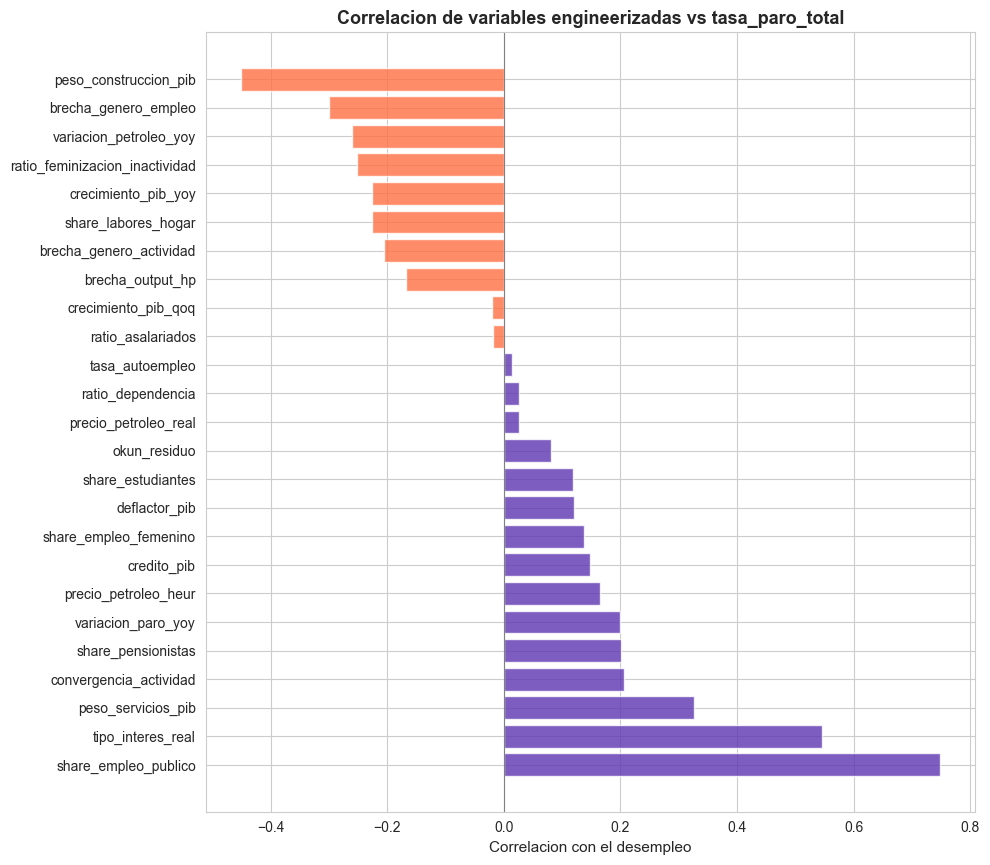

In [15]:
# Matriz de correlaciones con el objetivo
# Requiere que tasa_paro_total esté calculada
target_col = 'tasa_paro_total' if 'tasa_paro_total' in eng.columns else 'parados_total'

if target_col in eng.columns:
    corr_target = eng.corr()[target_col].drop(target_col).sort_values(ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, max(4, len(corr_target) * 0.35)))
    colores_corr = ['#5E35B1' if v >= 0 else '#FF7043' for v in corr_target.values]
    ax.barh(corr_target.index, corr_target.values, color=colores_corr, alpha=0.8)
    ax.axvline(0, color='gray', lw=0.8)
    ax.set_xlabel('Correlacion con el desempleo', fontsize=11)
    ax.set_title(f'Correlacion de variables engineerizadas vs {target_col}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

La correlación en nivel con el desempleo está dominada por variables estructurales con tendencia, no por las cíclicas, y por eso induce a error como criterio de prioridad. `share_empleo_publico` (correlación próxima a 0.74), `tipo_interes_real` (0.55) y `peso_construccion_pib` (-0.47) encabezan el ranking, pero esa asociación recoge tendencias compartidas a lo largo de cinco décadas, no capacidad predictiva: sobre el panel alineado por disponibilidad y en forma estacionaria sus correlaciones se desploman a -0.013, 0.045 y -0.056 respectivamente, prácticamente nulas. Es el patrón característico de la correlación espuria entre series tendenciales.

Las señales que conservan su correlación al estacionarizar son las cíclicas: `petroleo_yoy` se mantiene en -0.244, `crecimiento_pib_yoy` en -0.227 y `brecha_output_hp` en -0.167. El crecimiento del PIB conserva, e incluso refuerza, su correlación una vez alineado al rezago en que de verdad está disponible, coherente con que el desempleo es una variable conducida que reacciona al ciclo con retardo. Para la priorización de regresores esto invierte la lectura directa del gráfico: el orden en nivel no clasifica por valor predictivo, y la selección debe anclarse en las variables cuya relación con el paro sobrevive a la diferenciación y a la alineación temporal, no en las de correlación bruta más alta.

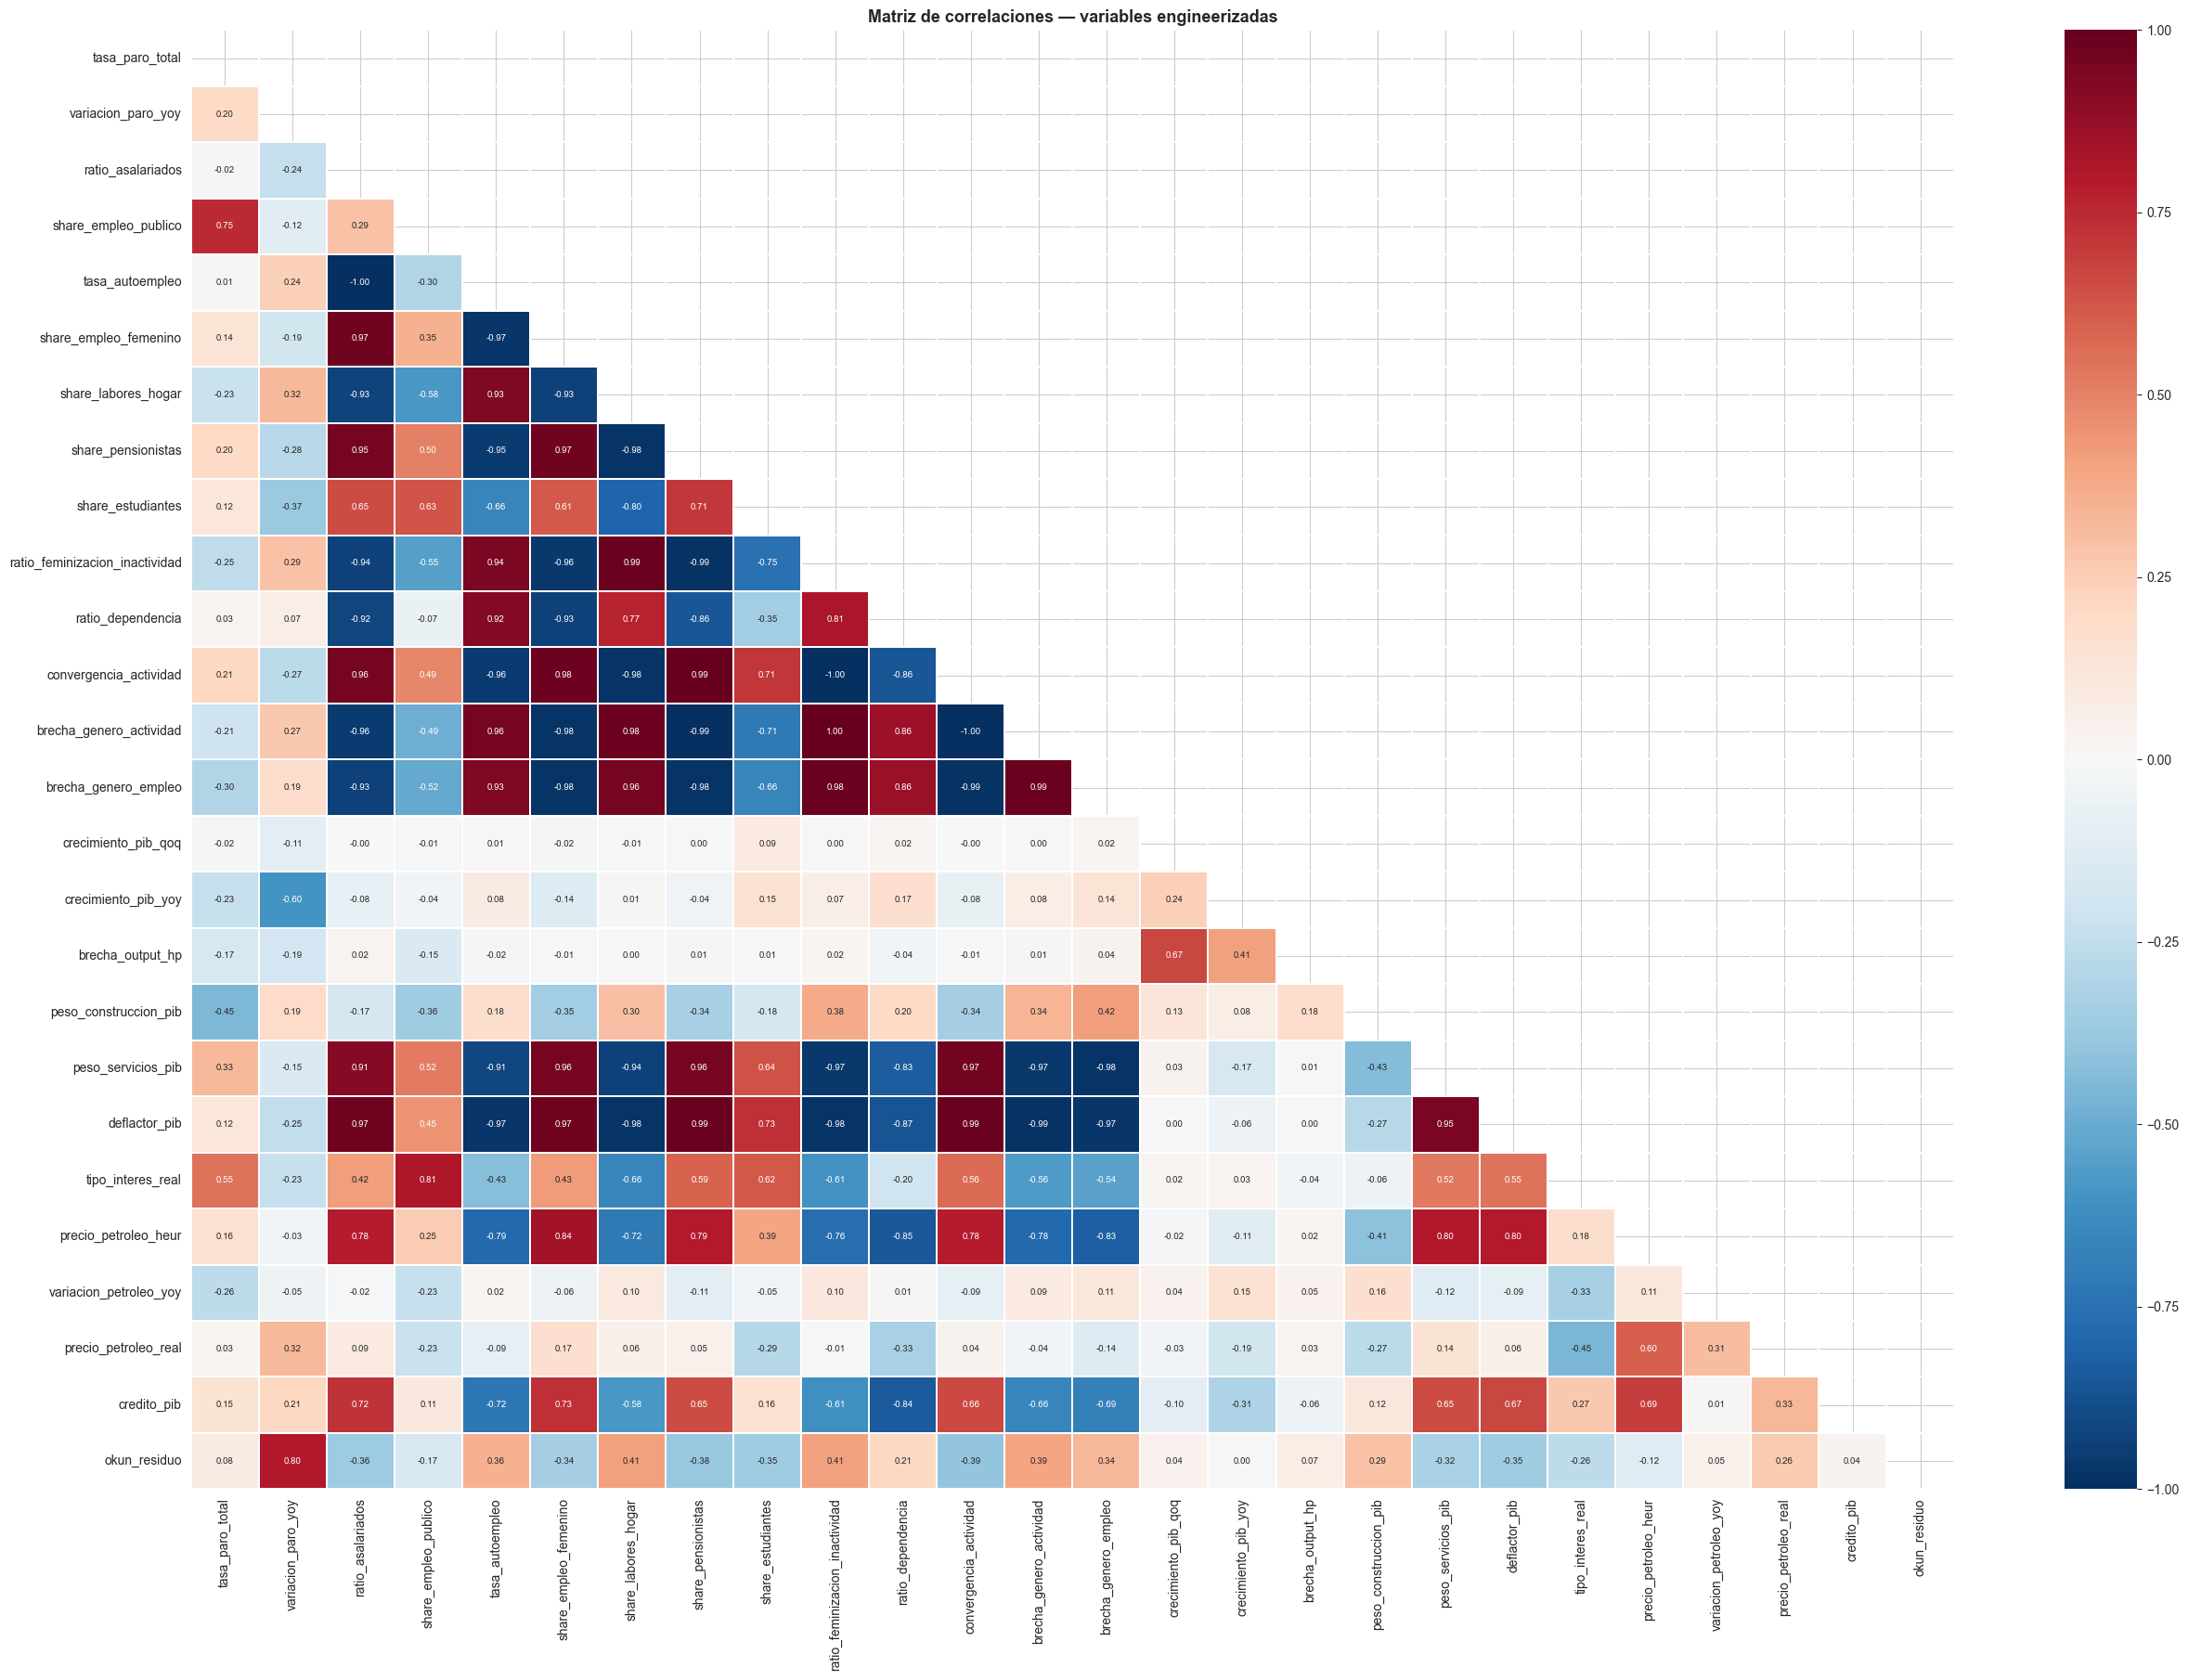

In [16]:
# Heatmap de correlaciones entre todas las variables
if len(eng.columns) > 1:
    fig, ax = plt.subplots(figsize=(max(10, len(eng.columns)), max(8, len(eng.columns) * 0.7)))
    mask = np.triu(np.ones_like(eng.corr(), dtype=bool))
    sns.heatmap(eng.corr(), ax=ax, mask=mask, cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, annot=True, fmt='.2f', annot_kws={'size': 7},
                linewidths=0.3)
    ax.set_title('Matriz de correlaciones — variables engineerizadas',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

La matriz revela dos bloques de intercorrelación densa que anticipan el problema de multicolinealidad del panel. El primero agrupa la composición laboral de la EPA (`share_empleo_publico`, `ratio_asalariados`, `tasa_autoempleo`, `share_empleo_femenino`, `share_labores_hogar`, `share_pensionistas`, `ratio_dependencia`, `convergencia_actividad` y las brechas de género), con correlaciones cruzadas elevadas porque todas comparten la deriva estructural del mercado de trabajo español. El segundo reúne el bloque macroeconómico y de precios, con el PIB y sus componentes, el IPRI y el petróleo solapados entre sí.

La estructura tiene dos consecuencias para el modelado. La poda de colinealidad será obligatoria en los modelos lineales y en el VECM, donde estos bloques degradan la estimación, mientras que los árboles la toleran. Y la fuerte correlación interna de cada bloque indica que cada uno es casi unidimensional: una extracción de factores por canal capturaría la mayor parte de su varianza en uno o dos componentes, lo que respalda comprimir cada bloque en lugar de arrastrar todas sus columnas redundantes.

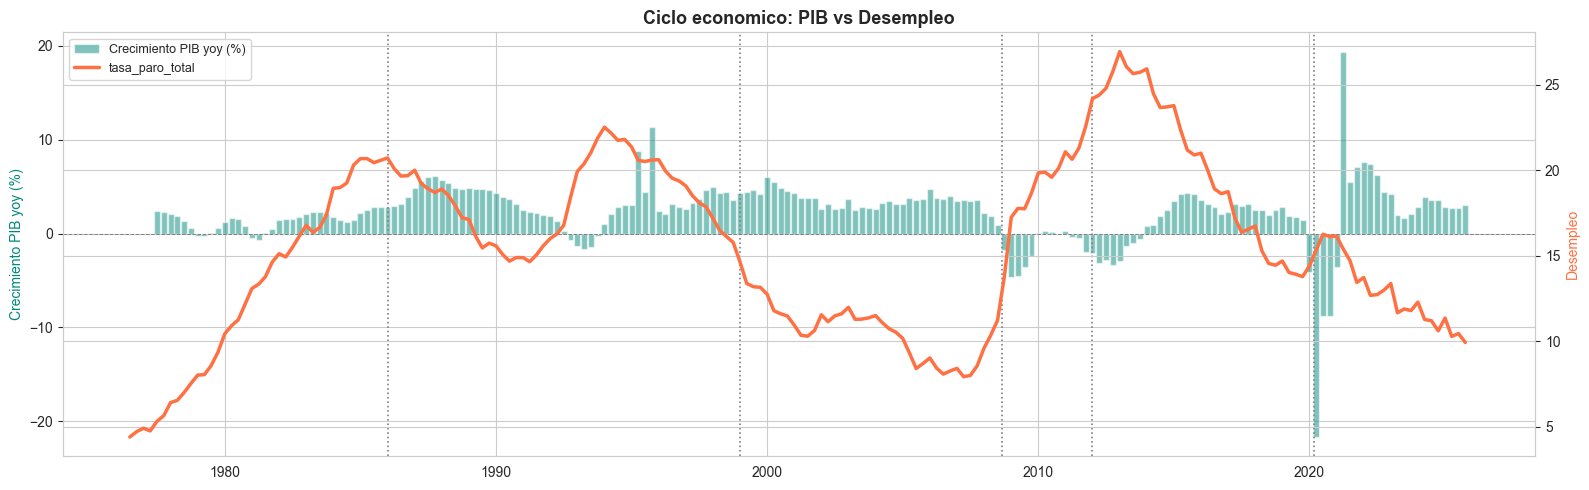

In [17]:
# Gráfica cíclica: PIB + desempleo en mismo plot (doble eje Y)
if 'crecimiento_pib_yoy' in eng_t.columns and target_col in eng_t.columns:
    fig, ax1 = plt.subplots(figsize=(16, 5))
    
    ax2 = ax1.twinx()
    ax1.bar(eng_t.index, eng_t['crecimiento_pib_yoy'], color='#00897B', alpha=0.5,
            width=80, label='Crecimiento PIB yoy (%)')
    ax2.plot(eng_t.index, eng_t[target_col], color='#FF7043', lw=2.5,
             label=target_col)
    
    ax1.set_ylabel('Crecimiento PIB yoy (%)', fontsize=10, color='#00897B')
    ax2.set_ylabel('Desempleo', fontsize=10, color='#FF7043')
    ax1.axhline(0, color='gray', lw=0.7, linestyle='--')
    
    for fecha_str, texto in EVENTOS.items():
        fecha_ev = pd.Timestamp(fecha_str)
        if eng_t.index.min() <= fecha_ev <= eng_t.index.max():
            ax1.axvline(fecha_ev, color='gray', linestyle=':', lw=1.2)
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
    ax1.set_title('Ciclo economico: PIB vs Desempleo', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

El desempleo se mueve en sentido inverso al crecimiento del PIB, con una asimetría marcada: las caídas del producto disparan el paro con rapidez y las recuperaciones lo reducen con lentitud. Las tres recesiones del periodo, la de 1993, la de 2008-2013 y la contracción de 2020, coinciden con los tres grandes ascensos del desempleo, que alcanza máximos de 20.72% en 1986, 22.52% en 1994 y 26.94% en 2013 antes de descender hasta el 9.93% en el cuarto trimestre de 2025.

La relación no es contemporánea ni simétrica: el repunte del paro persiste varios trimestres después de que el PIB recupera el crecimiento, reflejo de la histéresis del desempleo español. El shock de 2020 aparece como un pulso aislado en el PIB que no se traslada de forma proporcional al paro, amortiguado por los ERTE, lo que justifica tratarlo como evento puntual y no como cambio de régimen. Para el modelado, esta dinámica respalda incorporar el crecimiento del PIB rezagado y reservar los mecanismos de cambio de pendiente de la tendencia para las rupturas de 2008 y 2013.

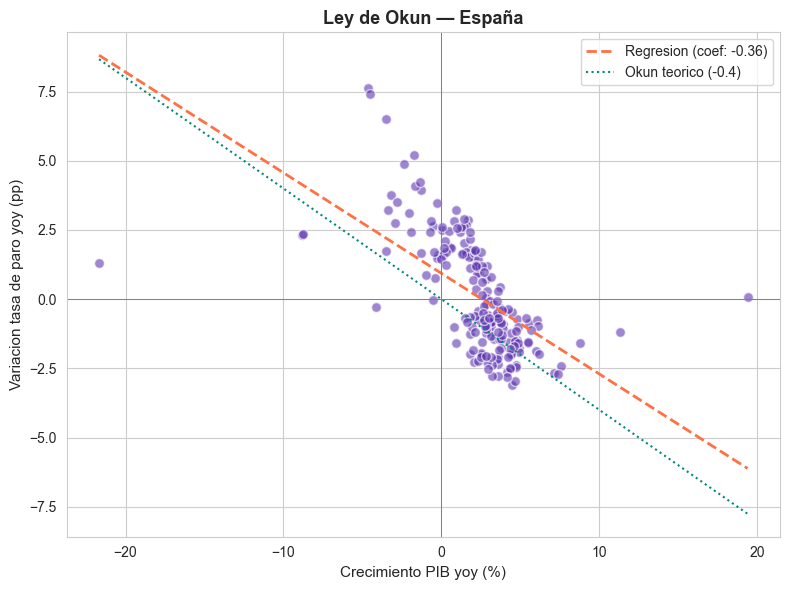

In [18]:
# Ley de Okun: scatter crecimiento PIB vs variación paro
if 'crecimiento_pib_yoy' in eng_t.columns and 'variacion_paro_yoy' in eng_t.columns:
    datos_okun = eng_t[['crecimiento_pib_yoy', 'variacion_paro_yoy']].dropna()
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(datos_okun['crecimiento_pib_yoy'], datos_okun['variacion_paro_yoy'],
               alpha=0.6, color=COLOR_PRINCIPAL, edgecolors='white', s=50)
    
    # Línea de regresión
    z = np.polyfit(datos_okun['crecimiento_pib_yoy'].dropna(),
                   datos_okun['variacion_paro_yoy'].dropna(), 1)
    p = np.poly1d(z)
    x_line = np.linspace(datos_okun['crecimiento_pib_yoy'].min(),
                         datos_okun['crecimiento_pib_yoy'].max(), 100)
    ax.plot(x_line, p(x_line), color='#FF7043', lw=2, linestyle='--',
            label=f'Regresion (coef: {z[0]:.2f})')
    
    # Línea teórica de Okun (-0.4)
    ax.plot(x_line, -0.4 * x_line, color='#00897B', lw=1.5, linestyle=':',
            label='Okun teorico (-0.4)')
    
    ax.axhline(0, color='gray', lw=0.7)
    ax.axvline(0, color='gray', lw=0.7)
    ax.set_xlabel('Crecimiento PIB yoy (%)', fontsize=11)
    ax.set_ylabel('Variacion tasa de paro yoy (pp)', fontsize=11)
    ax.set_title('Ley de Okun — España', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print('Okun: completar tasa_paro_total y variacion_paro_yoy para generar este grafico')

La ley de Okun describe la relación empírica entre el crecimiento económico y el desempleo: cuando la economía crece, el paro baja, pero no en la misma proporción, porque parte del crecimiento se absorbe por ganancias de productividad, por la ampliación de horas antes que de plantilla y por cambios en la población activa. En España la relación se cumple con un coeficiente de -0.364: cada punto porcentual de crecimiento interanual del PIB se asocia con una reducción de 0.36 puntos en la variación interanual del desempleo, muy cerca del -0.4 de referencia. La correlación entre ambas variables es de -0.597, la relación bilateral más robusta del panel y la única que se mantiene estable al pasar a forma estacionaria.

La dispersión de la nube alrededor de la recta es apreciable, coherente con que el PIB explica una parte del desempleo pero no toda: la histéresis, la dualidad del mercado laboral y la composición sectorial añaden varianza que el crecimiento agregado no recoge. Este coeficiente mide la relación contemporánea, la estructura económica; la versión operativa para pronóstico, con el PIB en el rezago en que de verdad está disponible, se trata en el análisis de rezagos. Para el modelado, el resultado consolida el crecimiento del PIB como regresor macroeconómico de referencia, con la cautela de la endogeneidad simultánea entre PIB y paro, que obliga a rezagarlo como predeterminado o a tratarlo como variable endógena en un sistema VAR o VECM.

### 5.1 Verificación de Estacionariedad: variables ingenierizadas
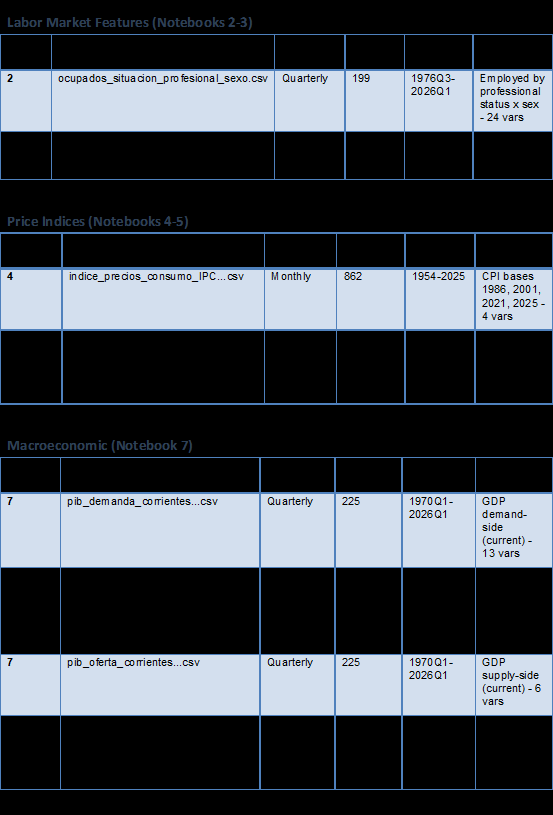

In [19]:
# -- 5.1 TEST DE ESTACIONARIEDAD ADF + KPSS SOBRE VARIABLES INGENIERIZADAS -----
# Criterio: ADF (H0 = raíz unitaria) y KPSS (H0 = estacionariedad)
from statsmodels.tsa.stattools import kpss
import warnings

def diagnostico_estacionariedad(serie, regression='c'):
    serie = serie.dropna()
    if len(serie) < 20:
        return None
    try:
        adf_stat, adf_p = adfuller(serie, autolag='AIC')[:2]
    except Exception:
        adf_stat, adf_p = np.nan, np.nan
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            kpss_stat, kpss_p = kpss(serie, regression=regression, nlags='auto')[:2]
    except Exception:
        kpss_stat, kpss_p = np.nan, np.nan
    adf_rechaza = adf_p < 0.05      # ADF rechaza H0 -> evidencia de ESTACIONARIEDAD
    kpss_rechaza = kpss_p < 0.05    # KPSS rechaza H0 -> evidencia de NO estacionariedad
    if adf_rechaza and not kpss_rechaza:
        decision = 'ESTACIONARIA'
    elif (not adf_rechaza) and kpss_rechaza:
        decision = 'NO ESTACIONARIA'
    elif (not adf_rechaza) and (not kpss_rechaza):
        decision = 'ZONA AMBIGUA (conservador: no estacionaria)'
    else:
        decision = 'CONTRADICCION (posible ruptura/outlier)'
    return {'ADF_stat': round(adf_stat, 4), 'ADF_p': round(adf_p, 4),
            'KPSS_stat': round(kpss_stat, 4), 'KPSS_p': round(kpss_p, 4),
            'decision': decision}

resultados_est = []
for variable in eng.columns:
    d = diagnostico_estacionariedad(eng[variable])
    if d is None:
        continue
    resultados_est.append({'variable': variable, **d})

df_est = pd.DataFrame(resultados_est).set_index('variable')
_orden = {'ESTACIONARIA': 0, 'ZONA AMBIGUA (conservador: no estacionaria)': 1,
          'CONTRADICCION (posible ruptura/outlier)': 2, 'NO ESTACIONARIA': 3}
df_est = df_est.sort_values('decision', key=lambda s: s.map(_orden))

n_estac = int((df_est['decision'] == 'ESTACIONARIA').sum())
print(f'Estacionariedad ADF+KPSS: {n_estac}/{len(df_est)} estacionarias limpias')
no_limpias = df_est[df_est['decision'] != 'ESTACIONARIA']
if len(no_limpias):
    print('\nNo estacionarias limpias (revisar forma/transformacion en feature engineering):')
    for v, row in no_limpias.iterrows():
        print(f'  {v}: {row["decision"]} (ADF p={row["ADF_p"]}, KPSS p={row["KPSS_p"]})')
display(df_est)

Estacionariedad ADF+KPSS: 6/26 estacionarias limpias

No estacionarias limpias (revisar forma/transformacion en feature engineering):
  precio_petroleo_real: ZONA AMBIGUA (conservador: no estacionaria) (ADF p=0.088, KPSS p=0.1)
  share_empleo_publico: CONTRADICCION (posible ruptura/outlier) (ADF p=0.0212, KPSS p=0.0443)
  tipo_interes_real: CONTRADICCION (posible ruptura/outlier) (ADF p=0.0, KPSS p=0.0117)
  share_pensionistas: CONTRADICCION (posible ruptura/outlier) (ADF p=0.049, KPSS p=0.01)
  share_estudiantes: NO ESTACIONARIA (ADF p=0.4114, KPSS p=0.01)
  ratio_feminizacion_inactividad: NO ESTACIONARIA (ADF p=0.3265, KPSS p=0.01)
  share_labores_hogar: NO ESTACIONARIA (ADF p=0.1272, KPSS p=0.01)
  share_empleo_femenino: NO ESTACIONARIA (ADF p=0.6691, KPSS p=0.01)
  ratio_asalariados: NO ESTACIONARIA (ADF p=0.8599, KPSS p=0.01)
  tasa_autoempleo: NO ESTACIONARIA (ADF p=0.8515, KPSS p=0.01)
  brecha_genero_actividad: NO ESTACIONARIA (ADF p=0.232, KPSS p=0.01)
  brecha_genero_empleo: 

,ADF_stat,ADF_p,KPSS_stat,KPSS_p,decision
variable,,,,,
tasa_paro_total,-3.093,0.027,0.147,0.100,ESTACIONARIA
variacion_paro_yoy,-3.309,0.015,0.243,0.100,ESTACIONARIA
crecimiento_pib_yoy,-3.639,0.005,0.158,0.100,ESTACIONARIA
crecimiento_pib_qoq,-4.390,0.000,0.107,0.100,ESTACIONARIA
variacion_petroleo_yoy,-3.969,0.002,0.080,0.100,ESTACIONARIA
brecha_output_hp,-5.212,0.000,0.023,0.100,ESTACIONARIA
precio_petroleo_real,-2.625,0.088,0.281,0.100,ZONA AMBIGUA (conservador: no estacionaria)
share_empleo_publico,-3.179,0.021,0.488,0.044,CONTRADICCION (posible ruptura/outlier)
tipo_interes_real,-4.905,0.000,0.720,0.012,CONTRADICCION (posible ruptura/outlier)


Solo 6 de las 26 variables ingenierizadas son estacionarias limpias en su forma natural, y todas son tasas de crecimiento o la brecha de producción: el objetivo en nivel, el crecimiento interanual e intertrimestral del PIB, la variación interanual del petróleo y la brecha de output del filtro Hodrick-Prescott. Son los objetos que ya nacen sin tendencia, con ambos contrastes convergiendo con holgura (KPSS en 0.100 y ADF por debajo de 0.01 en casi todos).

Las 20 restantes no estacionan en su forma natural por dos motivos distintos. El grueso son las variables de composición laboral y los ratios estructurales, como `ratio_asalariados`, `tasa_autoempleo`, `share_estudiantes`, `ratio_dependencia`, `peso_servicios_pib` o `credito_pib`, todas con el KPSS clavado en el suelo de 0.01: arrastran una tendencia estructural fuerte que exige diferenciación. Un segundo grupo, más pequeño, formado por `share_empleo_publico`, `tipo_interes_real` y `share_pensionistas`, produce contradicción entre ADF y KPSS, señal de ruptura o atípico antes que de raíz unitaria. Este diagnóstico es el que alimenta la asignación de forma por clase del panel maestro de la sección siguiente, donde cada variable recibe la transformación que le corresponde en lugar de descartarse por no estacionar en su forma de partida.

### 5.2 Panel maestro: conjunto candidato completo y dos formas según el tipo de modelo
Cada candidato pasa por el **recomendador** (nivel/diff1/diff4/var%) y se obtienen las **dos formas maestras**:
- `panel_estacionario` = todos en forma estacionaria, el **conjunto de candidatas de la selección**.
- `panel_nivel` = target + subconjunto I(1) para **VECM** (cointegración).

In [20]:
# -- 5.2 PANEL MAESTRO: conjunto candidato completo en dos formas (nivel y estacionaria) --

CANDIDATOS_MACRO = {
    'ipc':           ['IPC_2025', 'inflacion_yoy', 'inflacion_qoq'],
    'ipri':          ['IPRI_total_industria_2025', 'IPRI_energia_2025', 'IPRI_bienes_equipo_2025',
                      'IPRI_bienes_intermedios_2025', 'IPRI_bienes_consumo_2025',
                      'prima_energia', 'spread_equipo_consumo', 'ipri_yoy'],
    'ipi':           ['ipi_constantes_2025_total_industria', 'ipi_constantes_2025_energia',
                      'ipi_constantes_2025_bienes_equipo', 'ipi_constantes_2025_bienes_intermedios',
                      'ipi_constantes_2025_bienes_consumo'],
    'tipo_cambio':   ['HEUR_USD', 'HEUR_GBP', 'HEUR_CHF', 'heur_usd_yoy_pct',
                      'volatilidad_30d', 'spread_gbp_usd'],
    'tipos_interes': ['interes_legal', 'diferencial', 'cambio_tipo'],
    'petroleo':      ['usd_barril', 'yoy_pct', 'volatilidad_30d'],
    'banca_activo':  ['ed_activo_total', 'ed_activo_credito_sector_privado',
                      'credito_privado_share', 'crecimiento_credito_yoy'],
    'banca_pasivo':  ['ed_pasivo_depositos_total', 'ed_pasivo_sector_privado',
                      'crecimiento_depositos_yoy', 'ed_pasivo_sector_privado_share'],
    'pib_demanda':   ['fbcf', 'consumo_privado_nacional', 'consumo_publico',
                      'exportacion_bienes_servicios', 'importacion_bienes_servicios',
                      'tasa_inversion', 'apertura_comercial', 'saldo_comercial_pct_pib',
                      'consumo_publico_pct_pib'],
    'pib_oferta':    ['vab_industria', 'vab_construccion', 'vab_agricultura'],
}

target_col = 'tasa_paro_total'

# Conjunto candidato en su forma original: derivadas inter-dataset, composición EPA y regresores
# macro (CANDIDATOS_MACRO). Se excluyen el target y su diferencia interanual del conjunto de regresores.
candidatas_nat = eng.drop(columns=[c for c in [target_col, 'variacion_paro_yoy'] if c in eng.columns]).copy()
_avisos = []
for ds, cols in CANDIDATOS_MACRO.items():
    for c in cols:
        full = col(ds, c)
        if full in panel.columns:
            nombre = c if c not in candidatas_nat.columns else f'{ds}__{c}'
            candidatas_nat[nombre] = panel[full].shift(LAG_PUB_DS[ds])
        else:
            _avisos.append(full)
if _avisos:
    print(f'Aviso: {len(_avisos)} candidatos no hallados en el panel: {_avisos}')

# El yoy del crudo se conserva en su versión de mayor granularidad (calculada en la limpieza), con
# nombre legible. usd_barril (var% recalculado) y variacion_petroleo_yoy quedan fuera (EXCLUIR_MANUAL).
candidatas_nat = candidatas_nat.rename(columns={'yoy_pct': 'petroleo_yoy', 'precio_petroleo_real': 'precio_petroleo_real2025'})

# La forma estacionaria la fija el diagnóstico del EDA de cada variable, no la primera transformacion
# que pase un test. La forma de ficha (la que el EDA 0-11 adoptó para la variable PRINCIPAL de cada
# dataset, la más correcta sin inducir correlación espuria) actúa como prior. Las derivadas no heredan
# la forma de su principal: se tratan por clase de objeto. ADF y KPSS son diagnóstico, no veto: una
# forma elegida por su economía (homocedasticidad, ausencia de estacionalidad residual) se respeta
# aunque el contraste resulte marginal. El automatismo nivel -> diff1 -> diff4 -> var% queda solo como
# fallback para lo que no tiene ni ficha ni clase.

FORMA_DE_FICHA = {
    'IPC_2025':                            'diff1',
    'IPRI_total_industria_2025':           'diff1',
    'HEUR_USD':                            'diff1',
    'interes_legal':                       'diff1',
    'ed_pasivo_depositos_total':           'diff1',
    'ipi_constantes_2025_total_industria': 'var%',
    'ed_activo_total':                     'var%',
    'crecimiento_pib_yoy':                 'nivel',   # ya es la variación interanual del PIB (forma de ficha)
}

FORMA_DE_CLASE = {
    # componentes de producción industrial con var% limpia; los que solo estacionan en diff1
    # estacional se excluyen por redundancia con el total (ver EXCLUIR_MANUAL)
    'ipi_constantes_2025_bienes_equipo':      'var%',
    'ipi_constantes_2025_bienes_intermedios': 'var%',
    # componentes y derivadas del IPRI: diff1 como el IPRI total
    'IPRI_energia_2025':            'diff1',
    'IPRI_bienes_intermedios_2025': 'diff1',
    'IPRI_bienes_consumo_2025':     'diff1',
    'prima_energia':                'diff1',
    # otros tipos de cambio: diff1 como HEUR_USD
    'HEUR_GBP': 'diff1',
    'HEUR_CHF': 'diff1',
    # shares con tendencia estructural cuya diff1 estaciona; las que no (femenino, pensionistas)
    # caen al fallback y se excluyen como tendencias demograficas no estacionarizables
    'share_labores_hogar': 'diff1',
    'apertura_comercial':  'diff1',
    'tasa_inversion':          'nivel',   # ratio mean-reverting
    'saldo_comercial_pct_pib': 'diff1',   # tendencia estructural (paso a superávit tras 2008)
}

# Exclusión documentada por redundancia (no por falta de forma): componentes del IPI cuya única forma
# estacionaria es diff1, que retiene la estacionalidad industrial; el IPI total ya entra limpio en
# var% y los cubre.
EXCLUIR_MANUAL = {
    'ipi_constantes_2025_energia':        'diff1 estaciona pero retiene estacionalidad; redundante con el IPI total (var%)',
    'ipi_constantes_2025_bienes_consumo': 'diff1 estaciona pero retiene estacionalidad; redundante con el IPI total (var%)',
    'usd_barril':                         'duplicado: su yoy es petroleo_yoy, mismo concepto mejor calculado en alta frecuencia',
    'variacion_petroleo_yoy':             'duplicado del yoy del crudo (r=0.93 con petroleo_yoy); se conserva petroleo_yoy',
    'precio_petroleo_heur':               'duplicado del nivel del crudo (r=0.91 con precio_petroleo_real2025); se conserva el real deflactado',
}

def aplicar_forma(serie, forma):
    if forma == 'nivel': return serie
    if forma == 'diff1': return serie.diff()
    if forma == 'diff4': return serie.diff(4)
    if forma == 'var%':  return serie.pct_change(4) * 100
    return None

def _formas_disponibles(serie):
    formas = ['nivel', 'diff1', 'diff4']
    s = serie.dropna()
    if len(s) and s.min() > 0:        # var% (pct_change) solo tiene sentido en series estrictamente positivas
        formas.append('var%')
    return formas

def recomendar_forma(nombre, serie):
    disp = _formas_disponibles(serie)
    diag = {f: diagnostico_estacionariedad(aplicar_forma(serie, f)) for f in disp}
    asignada, origen = FORMA_DE_FICHA.get(nombre), 'ficha'
    if asignada is None:
        asignada, origen = FORMA_DE_CLASE.get(nombre), 'clase'
    if asignada == 'var%' and 'var%' not in disp:    # forma asignada imposible (serie no positiva): cae a fallback
        asignada = None
    if asignada is not None:
        d = diag.get(asignada)
        dec = d['decision'] if d else 'sin test'
        nota = '' if dec == 'ESTACIONARIA' else f'{origen}: {dec}'
        return asignada, aplicar_forma(serie, asignada), origen, d, nota
    for f in disp:        # fallback: primera forma estacionaria en el orden de parsimonia
        d = diag.get(f)
        if d and d['decision'] == 'ESTACIONARIA':
            return f, aplicar_forma(serie, f), 'automatico', d, ''
    return None, None, 'excluida', None, 'ninguna forma estaciona'

panel_estacionario = pd.DataFrame(index=candidatas_nat.index)
formas, EXCLUIR_NO_ESTAC = [], {}
for v in candidatas_nat.columns:
    if v in EXCLUIR_MANUAL:
        formas.append({'variable': v, 'origen': 'excluida', 'forma': 'EXCLUIDA',
                       'ADF_p': np.nan, 'KPSS_p': np.nan, 'decision': 'EXCLUIDA (redundante)',
                       'nota': EXCLUIR_MANUAL[v]})
        EXCLUIR_NO_ESTAC[v] = EXCLUIR_MANUAL[v]
        continue
    forma, st, origen, d, nota = recomendar_forma(v, candidatas_nat[v])
    formas.append({'variable': v, 'origen': origen, 'forma': forma if forma else 'EXCLUIDA',
                   'ADF_p': d['ADF_p'] if d else np.nan, 'KPSS_p': d['KPSS_p'] if d else np.nan,
                   'decision': d['decision'] if d else 'NINGUNA forma estaciona', 'nota': nota})
    if forma is None:
        EXCLUIR_NO_ESTAC[v] = nota
    else:
        panel_estacionario[v] = st

# target (I(0)) entra en su forma estacionaria = nivel
COL_TASA_PARO = col('poblacion', 'tasa_paro_ambos_sexos_total')
panel_estacionario[target_col] = eng[target_col] if target_col in eng.columns else panel[COL_TASA_PARO]

df_formas = pd.DataFrame(formas).set_index('variable')
n_estac = len(candidatas_nat.columns) - len(EXCLUIR_NO_ESTAC)
print(f'Candidatos totales: {len(candidatas_nat.columns)} | estacionarizados: {n_estac} | excluidos: {len(EXCLUIR_NO_ESTAC)}')
print('Formas:  ' + ' | '.join(f'{k}={int((df_formas["forma"]==k).sum())}' for k in ['nivel', 'diff1', 'diff4', 'var%']))
print('Origen:  ' + ' | '.join(f'{k}={int((df_formas["origen"]==k).sum())}' for k in ['ficha', 'clase', 'automatico', 'excluida']))
if EXCLUIR_NO_ESTAC:
    print(f'Excluidas: {sorted(EXCLUIR_NO_ESTAC)}')

# Reconciliación: formas adoptadas por ficha o clase cuyo contraste ADF+KPSS no es limpio. Son las
# decisiones a cerrar a mano (la forma económica se conserva, pero el test avisa de que es marginal).
revisar = df_formas[(df_formas['nota'] != '') & (df_formas['forma'] != 'EXCLUIDA')]
if len(revisar):
    print(f'\nA revisar ({len(revisar)}): forma de ficha/clase con contraste no limpio')
    display(revisar[['origen', 'forma', 'ADF_p', 'KPSS_p', 'decision']])

# panel_nivel: niveles del subconjunto I(1) para VECM (cointegración: paro + PIB + crédito privado)
VECM_NIVELES = {
    'tasa_paro':       col('poblacion', 'tasa_paro_ambos_sexos_total'),
    'pib_pm':          col('pib_demanda', 'pib_pm'),
    'credito_privado': col('banca_activo', 'ed_activo_credito_sector_privado'),
}
panel_nivel = pd.DataFrame(index=panel.index)
for nom, c in VECM_NIVELES.items():
    if c in panel.columns:
        panel_nivel[nom] = panel[c]

# El panel estacionario completo es el conjunto de candidatas que alimenta la selección siguiente
eng = panel_estacionario
print(f'\npanel_estacionario (candidatas seleccion): {panel_estacionario.shape[1]} columnas (incl. target)')
print(f'panel_nivel (subset VECM): {list(panel_nivel.columns)}')
display(df_formas)


Candidatos totales: 72 | estacionarizados: 55 | excluidos: 17
Formas:  nivel=9 | diff1=40 | diff4=2 | var%=4
Origen:  ficha=8 | clase=12 | automatico=35 | excluida=17
Excluidas: ['IPRI_bienes_equipo_2025', 'brecha_genero_actividad', 'convergencia_actividad', 'credito_pib', 'deflactor_pib', 'ed_activo_credito_sector_privado', 'ed_pasivo_sector_privado', 'ipi_constantes_2025_bienes_consumo', 'ipi_constantes_2025_energia', 'precio_petroleo_heur', 'ratio_dependencia', 'ratio_feminizacion_inactividad', 'share_empleo_femenino', 'share_pensionistas', 'spread_equipo_consumo', 'usd_barril', 'variacion_petroleo_yoy']

A revisar (5): forma de ficha/clase con contraste no limpio


,origen,forma,ADF_p,KPSS_p,decision
variable,,,,,
share_labores_hogar,clase,diff1,0.163,0.065,ZONA AMBIGUA (conservador: no estacionaria)
HEUR_CHF,clase,diff1,0.000,0.018,CONTRADICCION (posible ruptura/outlier)
ed_activo_total,ficha,var%,0.246,0.019,NO ESTACIONARIA
ed_pasivo_depositos_total,ficha,diff1,0.055,0.100,ZONA AMBIGUA (conservador: no estacionaria)
tasa_inversion,clase,nivel,0.080,0.100,ZONA AMBIGUA (conservador: no estacionaria)



panel_estacionario (candidatas seleccion): 56 columnas (incl. target)
panel_nivel (subset VECM): ['tasa_paro', 'pib_pm', 'credito_privado']


,origen,forma,ADF_p,KPSS_p,decision,nota
variable,,,,,,
ratio_asalariados,automatico,diff1,0.001,0.100,ESTACIONARIA,
share_empleo_publico,automatico,diff1,0.004,0.054,ESTACIONARIA,
tasa_autoempleo,automatico,diff1,0.001,0.100,ESTACIONARIA,
share_empleo_femenino,excluida,EXCLUIDA,NaN,NaN,NINGUNA forma estaciona,ninguna forma estaciona
share_labores_hogar,clase,diff1,0.163,0.065,ZONA AMBIGUA (conservador: no estacionaria),clase: ZONA AMBIGUA (conservador: no estaciona...
...,...,...,...,...,...,...
saldo_comercial_pct_pib,clase,diff1,0.000,0.100,ESTACIONARIA,
consumo_publico_pct_pib,automatico,diff1,0.000,0.100,ESTACIONARIA,
vab_industria,automatico,diff1,0.001,0.100,ESTACIONARIA,


El panel maestro asigna a cada candidato su forma estacionaria por procedencia, no por un automatismo ciego: 8 formas proceden de la ficha de la variable principal, 12 de la regla de clase de las derivadas y 35 del recomendador automático para lo que no tiene ni ficha ni clase. El reparto resultante, diff1 en 40 variables, nivel en 9, var% en 4 y diff4 en 2, refleja que la diferencia regular es la forma dominante salvo en las series donde el diagnóstico individual impone una tasa de crecimiento homocedástica.

La tabla de reconciliación aísla cinco casos en los que la forma adoptada por ficha o clase no supera de forma limpia el doble contraste y se conserva por criterio económico antes que estadístico. Tres son marginales o ambiguos, `ed_pasivo_depositos_total`, `tasa_inversion` y `share_labores_hogar`, donde el contraste queda al borde y la forma de clase es la más razonable. `HEUR_CHF` produce contradicción por el atípico del desanclaje del franco suizo en 2015, no por falta de estacionariedad, y `ed_activo_total` se mantiene en su variación interanual por ser la referencia operativa del crédito pese a no estacionar limpio, con destino a árboles y Prophet y fuera de los modelos econométricos. Ninguna decisión queda oculta: la forma adoptada y su contraste se documentan variable a variable.

### 5.3 Rescate de candidatas: transformaciones adicionales interpretables

El recomendador base contrasta cuatro formas (nivel, diff1, diff4 y variación interanual), pero una candidata no debe darse por descartada si una transformación interpretable adicional la estacionariza. Antes de excluir una variable se prueban tres formas más, todas con lectura económica directa: la diferencia logarítmica trimestral (dlog1) y anual (dlog4), equivalentes a una tasa de crecimiento pero aditivas y más homocedásticas que la variación porcentual, y la variación intertrimestral (var% trimestral). Las tres exigen una serie estrictamente positiva, sin la cual una tasa de crecimiento carece de sentido.

El reensayo se limita a las candidatas cuya no estacionariedad proviene de una tendencia y que admiten una tasa de crecimiento: los agregados de crédito y depósitos y los ratios financieros (`credito_pib`, `deflactor_pib`, balances bancarios) y los índices industriales marcados. Quedan fuera de forma deliberada dos grupos. Las variables marcadas como contradicción (`share_pensionistas`, `spread_equipo_consumo`, `HEUR_CHF`) no sufren un problema de transformación sino de ruptura o atípico, como el desanclaje del franco suizo en 2015, que ninguna diferencia corrige y que corresponde a una variable de intervención en el modelado. Y los shares acotados de composición demográfica, sobre los que la diferencia logarítmica no tiene interpretación, por lo que reensayarlos no aportaría una forma con sentido.

In [21]:
# -- 5.3 RESCATE: transformaciones adicionales interpretables sobre candidatas no limpias ----
# Diagnóstico, no modifica el panel. Comprueba si una forma con sentido económico (tasa de
# crecimiento) estacionariza variables descartadas o marcadas por tendencia. Las de ruptura/outlier
# y los shares acotados quedan fuera por las razones de la celda anterior. Si alguna se rescata
# limpia, su forma se promueve después a FORMA_DE_CLASE en el recomendador.

def dlog1(s):  return np.log(s).diff() * 100        # crecimiento logarítmico trimestral
def dlog4(s):  return np.log(s).diff(4) * 100       # crecimiento logarítmico interanual
def varqoq(s): return s.pct_change(1) * 100         # variación intertrimestral %

EXTRA_FORMAS = {'dlog1': dlog1, 'dlog4': dlog4, 'var%_qoq': varqoq}

RESCATE = ['credito_pib', 'deflactor_pib',
           'ed_activo_credito_sector_privado', 'ed_pasivo_sector_privado',
           'ed_activo_total', 'ed_pasivo_depositos_total',
           'IPRI_bienes_equipo_2025', 'ipi_constantes_2025_energia',
           'ipi_constantes_2025_bienes_consumo']

filas = []
for v in RESCATE:
    if v not in candidatas_nat.columns:
        continue
    s = candidatas_nat[v]
    if s.dropna().min() <= 0:
        filas.append({'variable': v, 'forma': '(serie no positiva)',
                      'ADF_p': np.nan, 'KPSS_p': np.nan, 'decision': 'crecimiento no aplica'})
        continue
    for nom, f in EXTRA_FORMAS.items():
        d = diagnostico_estacionariedad(f(s))
        filas.append({'variable': v, 'forma': nom,
                      'ADF_p': d['ADF_p'] if d else np.nan,
                      'KPSS_p': d['KPSS_p'] if d else np.nan,
                      'decision': d['decision'] if d else 'sin test'})

df_rescate = pd.DataFrame(filas)
print('Veredicto del rescate (forma adicional interpretable que estaciona limpio):')
for v in df_rescate['variable'].unique():
    sub = df_rescate[df_rescate['variable'] == v]
    ok = sub.loc[sub['decision'] == 'ESTACIONARIA', 'forma'].tolist()
    estado = 'rescatable -> ' + ', '.join(ok) if ok else 'no rescatable con formas interpretables'
    print(f'  {v:36s} {estado}')

display(df_rescate.set_index(['variable', 'forma']))


Veredicto del rescate (forma adicional interpretable que estaciona limpio):
  credito_pib                          no rescatable con formas interpretables
  deflactor_pib                        no rescatable con formas interpretables
  ed_activo_credito_sector_privado     no rescatable con formas interpretables
  ed_pasivo_sector_privado             no rescatable con formas interpretables
  ed_activo_total                      no rescatable con formas interpretables
  ed_pasivo_depositos_total            no rescatable con formas interpretables
  IPRI_bienes_equipo_2025              no rescatable con formas interpretables
  ipi_constantes_2025_energia          no rescatable con formas interpretables
  ipi_constantes_2025_bienes_consumo   no rescatable con formas interpretables


ADF_p  KPSS_p  \
variable                           forma                     
credito_pib                        dlog1     0.084   0.100   
                                   dlog4     0.182   0.080   
                                   var%_qoq  0.069   0.100   
deflactor_pib                      dlog1     0.001   0.010   
                                   dlog4     0.001   0.010   
                                   var%_qoq  0.001   0.010   
ed_activo_credito_sector_privado   dlog1     0.165   0.053   
                                   dlog4     0.272   0.065   
                                   var%_qoq  0.165   0.052   
ed_pasivo_sector_privado           dlog1     0.052   0.100   
                                   dlog4     0.236   0.100   
                                   var%_qoq  0.051   0.100   
ed_activo_total                    dlog1     0.005   0.010   
                                   dlog4     0.276   0.017   
                                   var%_qoq  0.005   0.010   
ed_pasivo_depositos_total          dlog1     0.036   0.016   
                                   dlog4     0.185   0.024   
                                   var%_qoq  0.035   0.016   
IPRI_bienes_equipo_2025            dlog1     0.000   0.010   
                                   dlog4     0.001   0.010   
                                   var%_qoq  0.000   0.010   
ipi_constantes_2025_energia        dlog1     0.072   0.079   
                                   dlog4     0.326   0.010   
                                   var%_qoq  0.116   0.030   
ipi_constantes_2025_bienes_consumo dlog1     0.026   0.045   
                                   dlog4     0.153   0.010   
                                   var%_qoq  0.044   0.033   

                                                                                decision  
variable                           forma                                                  
credito_pib                        dlog1     ZONA AMBIGUA (conservador: no estacionaria)  
                                   dlog4     ZONA AMBIGUA (conservador: no estacionaria)  
                                   var%_qoq  ZONA AMBIGUA (conservador: no estacionaria)  
deflactor_pib                      dlog1         CONTRADICCION (posible ruptura/outlier)  
                                   dlog4         CONTRADICCION (posible ruptura/outlier)  
                                   var%_qoq      CONTRADICCION (posible ruptura/outlier)  
ed_activo_credito_sector_privado   dlog1     ZONA AMBIGUA (conservador: no estacionaria)  
                                   dlog4     ZONA AMBIGUA (conservador: no estacionaria)  
                                   var%_qoq  ZONA AMBIGUA (conservador: no estacionaria)  
ed_pasivo_sector_privado           dlog1     ZONA AMBIGUA (conservador: no estacionaria)  
                                   dlog4     ZONA AMBIGUA (conservador: no estacionaria)  
                                   var%_qoq  ZONA AMBIGUA (conservador: no estacionaria)  
ed_activo_total                    dlog1         CONTRADICCION (posible ruptura/outlier)  
                                   dlog4                                 NO ESTACIONARIA  
                                   var%_qoq      CONTRADICCION (posible ruptura/outlier)  
ed_pasivo_depositos_total          dlog1         CONTRADICCION (posible ruptura/outlier)  
                                   dlog4                                 NO ESTACIONARIA  
                                   var%_qoq      CONTRADICCION (posible ruptura/outlier)  
IPRI_bienes_equipo_2025            dlog1         CONTRADICCION (posible ruptura/outlier)  
                                   dlog4         CONTRADICCION (posible ruptura/outlier)  
                                   var%_qoq      CONTRADICCION (posible ruptura/outlier)  
ipi_constantes_2025_energia        dlog1     ZONA AMBIGUA (conservador: no estacionaria)  
                                   dlog4                      

### 5.4 Cierre de la sección: panel de formas estacionarias

El panel estacionario queda con 55 regresores y el objetivo, frente a 17 candidatos descartados. El reparto es diff1 en 40 variables, nivel en 9, var% en 4 y diff4 en 2, dominado por la diferencia regular salvo en las series donde la ficha impone una tasa de crecimiento homocedástica, como el PIB y la producción industrial.

La forma de cada variable no procede de la primera transformación que supera un contraste, sino del diagnóstico del análisis individual: la forma de ficha para las principales y la regla de clase para las derivadas, con ADF y KPSS como diagnóstico y no como veto. El reensayo con transformaciones adicionales interpretables, la diferencia logarítmica y la variación intertrimestral, confirmó que los agregados de crédito y depósitos no admiten una forma estacionaria limpia, coherente con su naturaleza de raíz casi unitaria, y que ninguna transformación corrige las series con ruptura.

Los diecisiete descartes se reparten en cuatro grupos: tendencias demográficas que la diferenciación no estabiliza, series con quiebre estructural que requieren una variable de intervención en el modelado, componentes industriales redundantes con su agregado ya limpio, y duplicados de información del precio del crudo, del que se conservan una sola medida de crecimiento interanual, la de mayor granularidad, y una sola de nivel, el precio real deflactado a 2025. El resultado es un panel honesto en el que cada columna entra en una forma estacionaria con interpretación económica, listo para la fase de selección.

---
## 6. Análisis por Subperiodos Históricos

In [22]:
# Definir subperiodos históricos
SUBPERIODOS = [
    ('Pre-UE',         '1976-07-01', '1985-12-31'),
    ('UE - pre-euro',  '1986-01-01', '1998-12-31'),
    ('Euro - pre-crisis', '1999-01-01', '2007-12-31'),
    ('Crisis financiera', '2008-01-01', '2013-12-31'),
    ('Recuperacion',   '2014-01-01', '2019-12-31'),
    ('Post-COVID',     '2020-01-01', '2099-12-31'),
]

# Estadísticas del target por subperiodo
if target_col in eng.columns:
    stats_periodos = []
    for nombre_p, inicio, fin in SUBPERIODOS:
        mascara = (eng.index >= inicio) & (eng.index <= fin)
        serie_p = eng.loc[mascara, target_col].dropna()
        if len(serie_p) > 0:
            stats_periodos.append({
                'Periodo': nombre_p,
                'Desde': serie_p.index.min().date(),
                'Hasta': serie_p.index.max().date(),
                'N':     len(serie_p),
                'Media': serie_p.mean().round(2),
                'Max':   serie_p.max().round(2),
                'Min':   serie_p.min().round(2),
                'Std':   serie_p.std().round(2),
            })
    
    df_periodos = pd.DataFrame(stats_periodos)
    print(f'Estadisticas de {target_col} por subperiodo:')
    display(df_periodos.set_index('Periodo'))

Estadisticas de tasa_paro_total por subperiodo:


,Desde,Hasta,N,Media,Max,Min,Std
Periodo,,,,,,,
Pre-UE,1976-07-01,1985-10-01,38,12.620,20.680,4.410,5.480
UE - pre-euro,1986-01-01,1998-10-01,52,18.370,22.520,14.650,2.310
Euro - pre-crisis,1999-01-01,2007-10-01,36,10.640,14.650,7.930,1.730
Crisis financiera,2008-01-01,2013-10-01,24,20.210,26.940,9.600,5.050
Recuperacion,2014-01-01,2019-10-01,24,18.790,25.930,13.780,3.850
Post-COVID,2020-01-01,2025-10-01,24,12.920,16.260,9.930,1.980


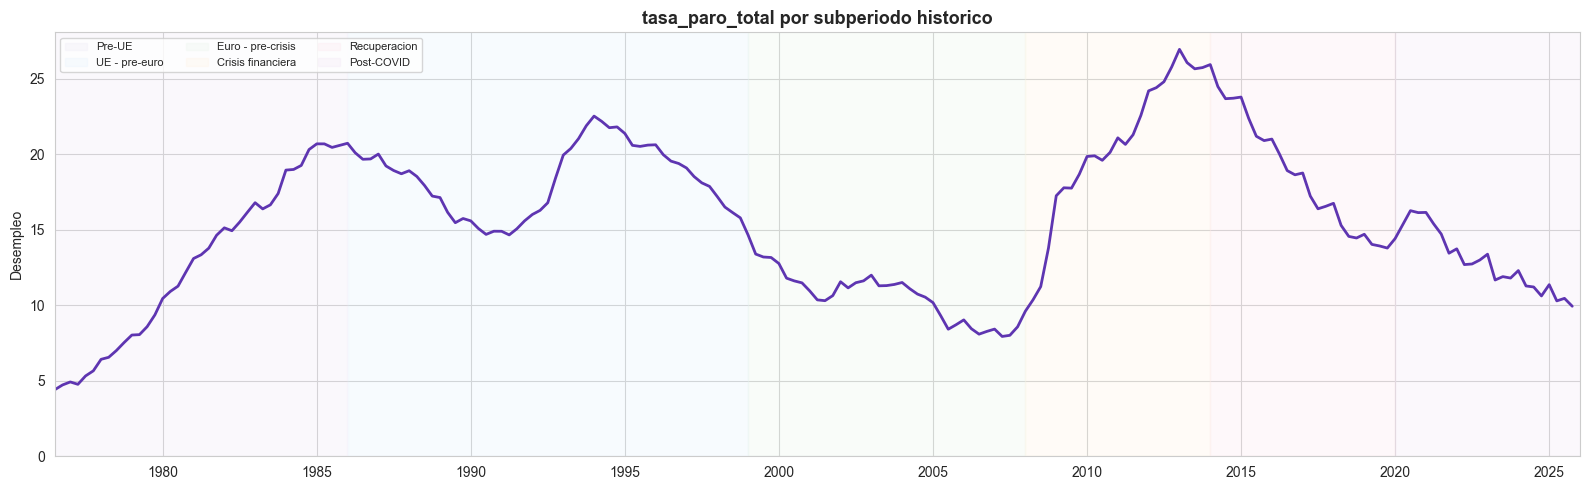

In [23]:
# Gráfica por subperiodos con fondos coloreados
if target_col in eng.columns:
    colores_p = ['#EDE7F6', '#E3F2FD', '#E8F5E9', '#FFF3E0', '#FCE4EC', '#F3E5F5']
    
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(eng.index, eng[target_col], color=COLOR_PRINCIPAL, lw=2)
    
    fin_eje = eng.index.max() + pd.DateOffset(months=3)   # un trimestre más allá del último dato (seguimos en Post-COVID)
    for (nombre_p, inicio, fin), color in zip(SUBPERIODOS, colores_p):
        ax.axvspan(pd.Timestamp(inicio), min(pd.Timestamp(fin), fin_eje),
                   alpha=0.25, color=color, label=nombre_p)
    ax.set_xlim(eng.index.min(), fin_eje)
    
    ax.set_title(f'{target_col} por subperiodo historico', fontsize=13, fontweight='bold')
    ax.set_ylabel('Desempleo', fontsize=10)
    ax.legend(fontsize=8, loc='upper left', ncol=3)
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.show()

La tasa de paro define seis regímenes con niveles y volatilidades netamente distintos, lo que respalda tratar las rupturas como cambios de pendiente en la fase de modelado. El periodo previo a la adhesión europea (1976-1985) combina un nivel medio de 12.62% con la mayor volatilidad del tramo inicial (desviación 5.48), reflejo del ascenso desde el 4.41% hasta el 20.68% durante la reconversión industrial. La etapa de la Unión Europea anterior al euro (1986-1998) se asienta en el nivel medio más alto de la serie, 18.37%, con la crisis de 1994 marcando el 22.52%.

La expansión previa a la crisis (1999-2007) es el régimen más benigno, con media de 10.64% y volatilidad mínima (1.73). La crisis financiera (2008-2013) produce el máximo histórico absoluto, 26.94%, y recupera la volatilidad extrema (5.05). La recuperación (2014-2019) desciende de forma sostenida desde ese pico, con media de 18.79%. El periodo post-COVID (2020-2025) cierra con media de 12.92% y el segundo nivel más bajo de la serie, 9.93%, pese al pico puntual de 16.26% en 2020.

La heterogeneidad de medias, de 10.64% a 20.21%, y de volatilidades, de 1.73 a 5.48, confirma que ningún proceso estacionario único describe la serie en nivel, y justifica la lista de changepoints suministrada a Prophet frente al uso de dummies de ruptura.

---
## 6.5 Diagnóstico de Multicolinealidad (Pipeline Prophet)

La multicolinealidad infla la varianza de los coeficientes en modelos lineales. En Prophet, los regresores entran linealmente, por lo que este diagnóstico es necesario para seleccionar un conjunto estable de variables.

Métodos:
1. **Matriz de correlación con umbral |r| > 0.85**: identifica pares altamente correlacionados.
2. **VIF (Variance Inflation Factor)**: VIF > 10 = multicolinealidad severa, VIF > 5 = moderada.

In [24]:
# ── 6.5a PARES CON ALTA CORRELACIÓN (|r| > 0.85) ────────────────────────────

from statsmodels.stats.outliers_influence import variance_inflation_factor

target_col = 'tasa_paro_total' if 'tasa_paro_total' in eng.columns else 'parados_total'
vars_candidatas_mc = [c for c in eng.columns if c != target_col]

corr_matrix = eng[vars_candidatas_mc].corr()

UMBRAL_CORR = 0.85
pares_alta_corr = []
for i in range(len(vars_candidatas_mc)):
    for j in range(i + 1, len(vars_candidatas_mc)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > UMBRAL_CORR:
            pares_alta_corr.append({
                'variable_1': vars_candidatas_mc[i],
                'variable_2': vars_candidatas_mc[j],
                'correlacion': round(r, 4),
            })

df_alta_corr = pd.DataFrame(pares_alta_corr).sort_values('correlacion', key=abs, ascending=False)

if len(df_alta_corr) > 0:
    print(f'Pares con |r| > {UMBRAL_CORR}: {len(df_alta_corr)}')
    display(df_alta_corr)
else:
    print(f'No hay pares con |r| > {UMBRAL_CORR}')

Pares con |r| > 0.85: 14


,variable_1,variable_2,correlacion
8,IPRI_energia_2025,prima_energia,0.988
0,ratio_asalariados,tasa_autoempleo,-0.969
4,peso_construccion_pib,vab_construccion,0.964
6,IPRI_total_industria_2025,IPRI_energia_2025,0.960
12,consumo_publico,consumo_publico_pct_pib,0.942
9,ipi_constantes_2025_total_industria,ipi_constantes_2025_bienes_intermedios,0.925
5,tipo_interes_real,inflacion_yoy,-0.907
7,IPRI_total_industria_2025,prima_energia,0.905
13,consumo_publico,vab_construccion,0.896
2,crecimiento_pib_qoq,vab_construccion,0.884


Catorce pares superan un coeficiente absoluto de 0.85 en forma estacionaria, lo que confirma que la redundancia del panel no es un artefacto de tendencia sino estructural. Se concentra en cinco bloques. El de precios energéticos es el más estrecho: `IPRI_energia` y `prima_energia` correlacionan 0.988, y ambas con `IPRI_total` por encima de 0.90. El bloque de producción y demanda agrupa `crecimiento_pib_qoq`, `fbcf`, `vab_construccion`, `consumo_publico` y `peso_construccion_pib`, todos entre sí por encima de 0.85, porque comparten el mismo pulso del ciclo inversor. La producción industrial repite el patrón entre el IPI total y sus componentes (0.926).

Dos pares recogen una variable que es combinación de otras dos, `tipo_interes_real` con `inflacion_yoy` (-0.907) y `HEUR_USD` con `spread_gbp_usd` (-0.875). Las complementarias de composición laboral cierran el cuadro, con `ratio_asalariados` y `tasa_autoempleo` a -0.969 por sumar prácticamente la unidad. Esta estructura obliga a descartar variables redundantes en los modelos lineales y el VECM, mientras que los árboles la toleran, y anticipa que cada bloque puede comprimirse en pocos factores.

Diagnostico VIF:
  VIF > 10 (severa):   24 variables
  VIF 5-10 (moderada): 8 variables
  VIF <= 5 (ok):       23 variables


,VIF,diagnostico
variable,,
IPRI_total_industria_2025,inf,SEVERA (>10)
IPRI_energia_2025,inf,SEVERA (>10)
prima_energia,inf,SEVERA (>10)
inflacion_yoy,inf,SEVERA (>10)
tipo_interes_real,inf,SEVERA (>10)
HEUR_GBP,inf,SEVERA (>10)
HEUR_USD,inf,SEVERA (>10)
spread_gbp_usd,inf,SEVERA (>10)
interes_legal,inf,SEVERA (>10)


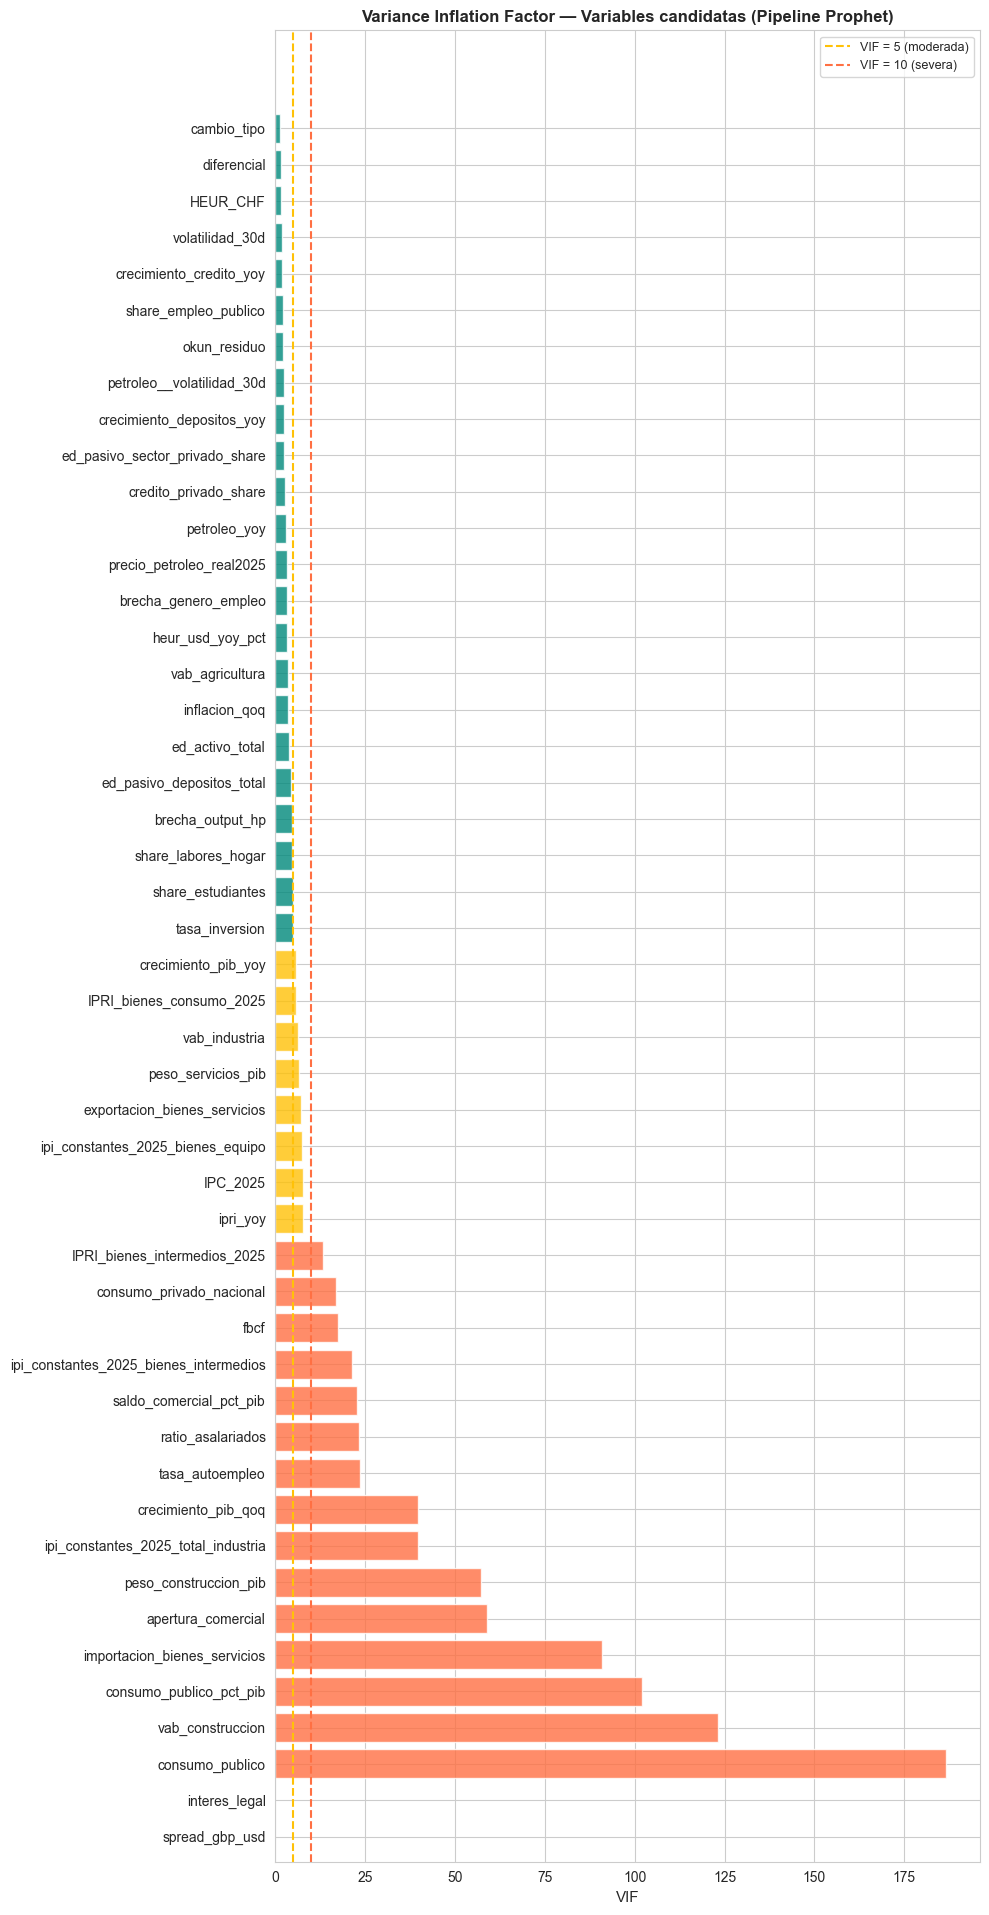

In [25]:
# ── 6.5b VIF (Variance Inflation Factor) ────────────────────────────────────

datos_vif = eng[vars_candidatas_mc].dropna()

scaler_vif = StandardScaler()
X_vif = scaler_vif.fit_transform(datos_vif)

vif_results = []
for i, variable in enumerate(vars_candidatas_mc):
    try:
        vif_val = variance_inflation_factor(X_vif, i)
        vif_results.append({'variable': variable, 'VIF': round(vif_val, 2)})
    except Exception:
        vif_results.append({'variable': variable, 'VIF': np.nan})

df_vif = pd.DataFrame(vif_results).sort_values('VIF', ascending=False)
df_vif['diagnostico'] = df_vif['VIF'].apply(
    lambda v: 'SEVERA (>10)' if v > 10 else ('moderada (>5)' if v > 5 else 'ok')
)

print('Diagnostico VIF:')
print(f'  VIF > 10 (severa):   {(df_vif["VIF"] > 10).sum()} variables')
print(f'  VIF 5-10 (moderada): {((df_vif["VIF"] > 5) & (df_vif["VIF"] <= 10)).sum()} variables')
print(f'  VIF <= 5 (ok):       {(df_vif["VIF"] <= 5).sum()} variables')

display(df_vif.set_index('variable'))

# Gráfica VIF
fig, ax = plt.subplots(figsize=(10, max(4, len(df_vif) * 0.35)))
colores_vif = ['#FF7043' if v > 10 else ('#FFC107' if v > 5 else '#00897B') for v in df_vif['VIF']]
ax.barh(df_vif['variable'], df_vif['VIF'], color=colores_vif, alpha=0.8)
ax.axvline(5, color='#FFC107', lw=1.5, linestyle='--', label='VIF = 5 (moderada)')
ax.axvline(10, color='#FF7043', lw=1.5, linestyle='--', label='VIF = 10 (severa)')
ax.set_xlabel('VIF', fontsize=11)
ax.set_title('Variance Inflation Factor — Variables candidatas (Pipeline Prophet)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

El VIF mide cada variable contra todas las demás a la vez, no por pares, y por eso captura dependencias que la correlación bilateral no ve: nueve variables alcanzan un VIF infinito, señal de que son combinación lineal exacta del resto. Son las tres combinaciones exactas del panel y sus componentes: el tipo de interés real, que es el tipo legal menos la inflación; el diferencial cambiario, que es la resta de sus dos tipos; y la prima energética, que es el IPRI de energía menos el total. Mientras cada combinación y sus dos componentes estén juntos, la matriz de diseño es singular y ningún modelo lineal puede estimarse.

Por debajo del infinito, otras variables superan con holgura el umbral severo de 10, encabezadas por el bloque de demanda y construcción (`consumo_publico` 187, `vab_construccion` 123, `importacion_bienes_servicios` 91) que ya aparecía en la tabla de pares, mientras 23 quedan en zona aceptable. La lectura para el modelado es directa: el VIF infinito es estructural y se resuelve descartando la variable redundante de cada combinación, lo que se hace en la celda siguiente para la vista lineal; la colinealidad severa pero finita se gestiona en la selección dentro del expanding window y la toleran los árboles.

In [ ]:
# ── 6.5c RESOLUCIÓN DE MULTICOLINEALIDAD (Prophet) ──────────────────────────
# Criterio: ante un VIF alto se retiene la variable con mayor relevancia teórica para predecir el desempleo; cada descartada lleva su motivo documentado en EXCLUIR_PROPHET.

EXCLUIR_PROPHET = {
    'tipo_interes_real': 'Variable redundante: se obtiene como interes_legal menos inflacion_yoy (VIF infinito). Se conservan las dos primitivas, casi ortogonales (r=0.07).',
    'spread_gbp_usd':    'Variable redundante: se obtiene como HEUR_GBP menos HEUR_USD (VIF infinito). Se conservan los dos tipos de cambio (r=0.47).',
    'prima_energia':     'Variable redundante: se obtiene como IPRI_energia menos IPRI_total (VIF infinito). El bloque de precios energeticos se reduce a IPRI_total.',
    'IPRI_energia_2025': 'Redundante con IPRI_total (r=0.96); el bloque de precios industriales se reduce a un representante en la vista lineal.',
}

vars_post_vif = [v for v in vars_candidatas_mc if v not in EXCLUIR_PROPHET]

print(f'Variables candidatas originales: {len(vars_candidatas_mc)}')
print(f'Excluidas por multicolinealidad (Prophet): {len(EXCLUIR_PROPHET)}')
print(f'Variables post-VIF para Prophet: {len(vars_post_vif)}')

if EXCLUIR_PROPHET:
    print('\nExclusiones:')
    for var, motivo in EXCLUIR_PROPHET.items():
        print(f'  {var}: {motivo}')

La resolución descarta cuatro variables redundantes para la vista lineal y Prophet, y deja 51 de las 55 candidatas. Tres son la variable que sobra en cada combinación exacta, `tipo_interes_real`, `spread_gbp_usd` y `prima_energia`, cuya retirada devuelve a las primitivas su independencia: una vez fuera, el tipo legal y la inflación quedan casi ortogonales (0.07) y los dos tipos de cambio en una correlación moderada (0.47). La cuarta, `IPRI_energia`, se retira porque el bloque de precios industriales correlaciona por encima de 0.96 y basta con un representante, `IPRI_total`.

El descarte afecta solo a los modelos que sufren la colinealidad, los lineales, el VECM y Prophet por su carácter aditivo; los árboles conservan el panel completo porque la toleran y la interpretan después con SHAP. Además no es vinculante para el modelo final, ya que la selección definitiva va embebida en cada pliegue del expanding window. Esta celda deja un conjunto lineal sin singularidades del que parten el Lasso del bloque siguiente y la exportación de la vista Prophet.

---
## 7. Selección de Variables para Modelado

Dos pipelines independientes adaptados a las propiedades de cada familia de modelos:

### Pipeline A (Prophet, regresores lineales)
1. Post-VIF: solo variables que pasaron el filtro de multicolinealidad (sección 6.5).
2. Causalidad de Granger (lags 1-8, significancia al 10%).
3. LASSO con validación cruzada temporal (TimeSeriesSplit, 5 folds).
4. Criterio: Granger significativo al 10% OR LASSO coef distinto de 0.
5. **Tabla de recomendación**, revisión semi-manual con criterio económico.

### Pipeline B (Árboles: XGBoost, Random Forest)
1. Sin filtro VIF (los árboles manejan la colinealidad de forma nativa).
2. Causalidad de Granger (lags 1-8, umbral generoso al 20%) OR cross-correlación |r| > 0.2.
3. Sin LASSO (evita el sesgo lineal en la preselección).
4. **Tabla de recomendación**, revisión semi-manual.
5. Interpretabilidad post-modelado: permutation importance y SHAP (en los notebooks de modelado).

In [27]:
# ── 7.1 CAUSALIDAD DE GRANGER ─────────────────────────────────────────────────
# Se ejecuta sobre TODAS las variables candidatas (vars_candidatas_mc).
# El filtrado por pipeline (Prophet post-VIF vs Trees) se aplica en la tabla final.

resultados_granger = []

if target_col in eng.columns and len(vars_candidatas_mc) > 0:
    print(f'Test de Granger: {len(vars_candidatas_mc)} variables candidatas vs {target_col}...')
    
    for var in vars_candidatas_mc:
        try:
            datos_gc = eng[[target_col, var]].dropna()
            if len(datos_gc) < 20:
                continue
            gc = grangercausalitytests(datos_gc, maxlag=8, verbose=False)
            p_min = min(gc[lag][0]['ssr_ftest'][1] for lag in range(1, 9))
            lag_mejor = min(range(1, 9), key=lambda l: gc[l][0]['ssr_ftest'][1])
            resultados_granger.append({
                'variable': var,
                'granger_p_min': round(p_min, 4),
                'granger_lag_opt': lag_mejor,
                'granger_sig_5pct': p_min < 0.05,
                'granger_sig_10pct': p_min < 0.10,
                'granger_sig_20pct': p_min < 0.20,
            })
        except Exception:
            resultados_granger.append({
                'variable': var,
                'granger_p_min': np.nan, 'granger_lag_opt': np.nan,
                'granger_sig_5pct': False, 'granger_sig_10pct': False,
                'granger_sig_20pct': False,
            })
    
    df_granger = pd.DataFrame(resultados_granger).sort_values('granger_p_min')
    print(f'Significativas al 5%:  {df_granger.granger_sig_5pct.sum()}')
    print(f'Significativas al 10%: {df_granger.granger_sig_10pct.sum()}')
    print(f'Significativas al 20%: {df_granger.granger_sig_20pct.sum()}')
    display(df_granger)
else:
    print(f'Variable objetivo {target_col} no disponible.')
    df_granger = pd.DataFrame()

Test de Granger: 55 variables candidatas vs tasa_paro_total...
Significativas al 5%:  47
Significativas al 10%: 50
Significativas al 20%: 53


,variable,granger_p_min,granger_lag_opt,granger_sig_5pct,granger_sig_10pct,granger_sig_20pct
3,share_labores_hogar,0.000,3,True,True,True
6,crecimiento_pib_qoq,0.000,3,True,True,True
5,brecha_genero_empleo,0.000,1,True,True,True
4,share_estudiantes,0.000,3,True,True,True
7,crecimiento_pib_yoy,0.000,1,True,True,True
10,peso_servicios_pib,0.000,4,True,True,True
9,peso_construccion_pib,0.000,4,True,True,True
8,brecha_output_hp,0.000,5,True,True,True
14,IPC_2025,0.000,4,True,True,True
25,ipi_constantes_2025_bienes_intermedios,0.000,1,True,True,True


El test de Granger señala 47 de las 55 candidatas como significativas al 5% y 53 al 20%, una proporción tan alta que lo inhabilita como filtro de selección. Con cerca de 198 observaciones trimestrales y series persistentes, el contraste sobre-rechaza: la inercia compartida entre regresores y desempleo basta para que casi cualquier variable anticipe al paro en sentido de Granger, sin que ello implique poder predictivo genuino fuera de muestra.

La lectura útil no es el listado de significativas sino el rezago óptimo asociado, que ordena las variables por su horizonte de relación con el paro. El bloque de precios industriales y energía sitúa su mínimo p-valor en rezagos largos, de cuatro a cinco trimestres, coherente con su papel de indicador adelantado, mientras que el PIB y la brecha de producción lo hacen en rezagos cortos. La consecuencia para el modelado es que la causalidad de Granger se usa aquí como contexto descriptivo del adelanto temporal, no como criterio de inclusión, que se reserva al Lasso, al prior económico y a la selección embebida en validación cruzada.

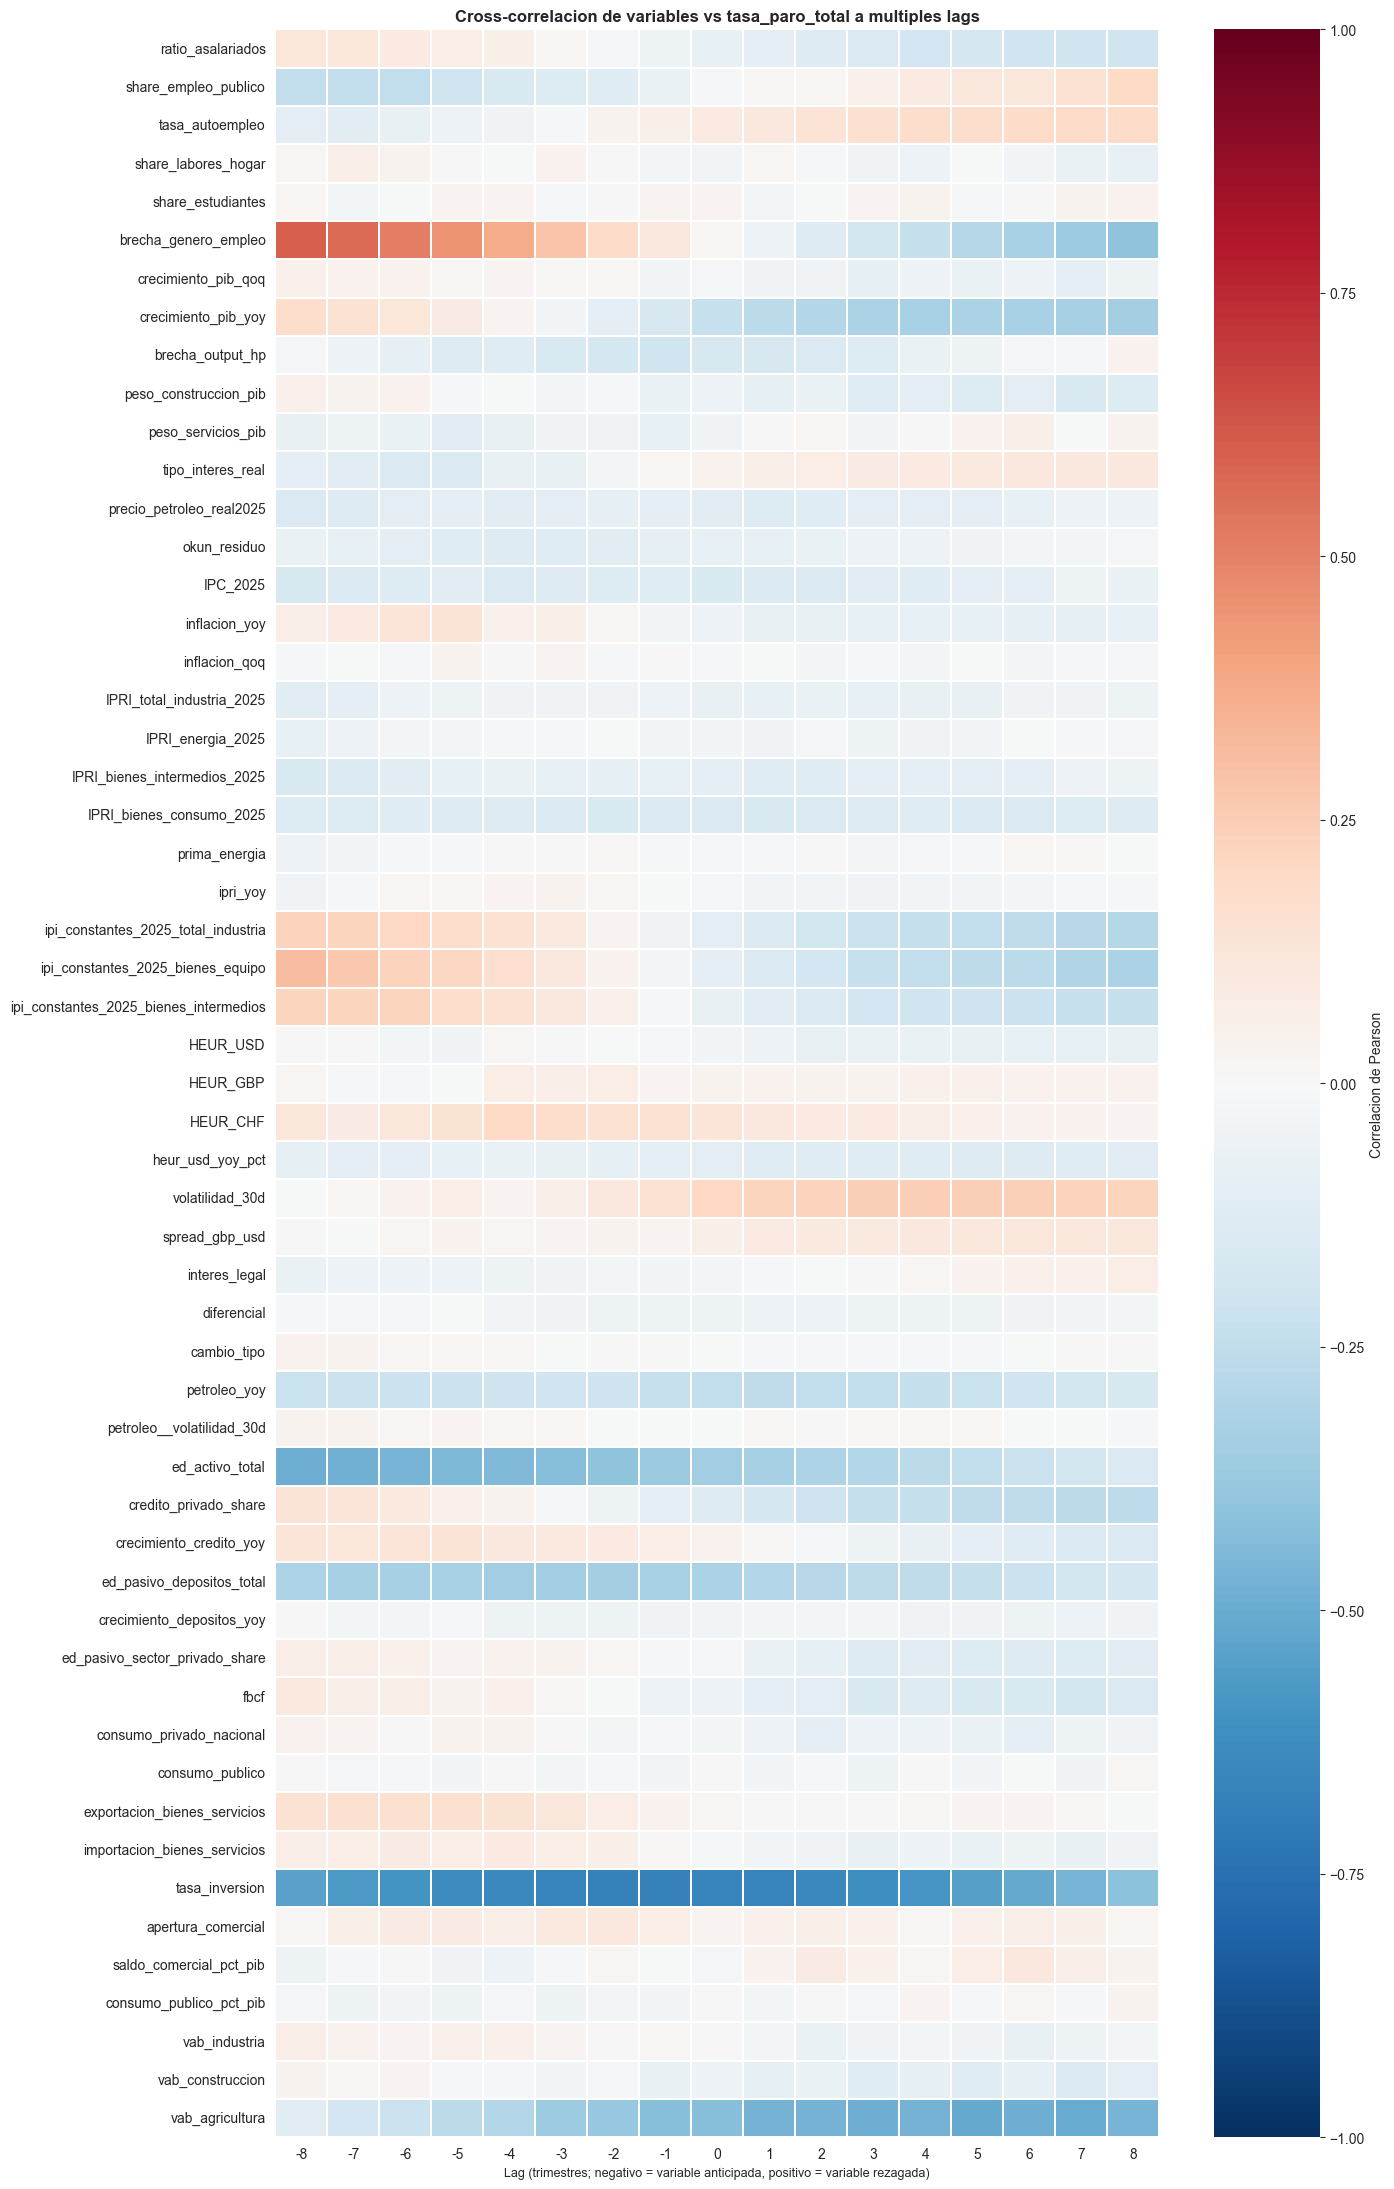

Lag de maxima correlacion absoluta con el target:
                                        lag_max_corr_abs
share_empleo_publico                                  -8
brecha_genero_empleo                                  -8
precio_petroleo_real2025                              -8
IPC_2025                                              -8
prima_energia                                         -8
IPRI_bienes_intermedios_2025                          -8
IPRI_energia_2025                                     -8
IPRI_total_industria_2025                             -8
petroleo__volatilidad_30d                             -8
ed_activo_total                                       -8
cambio_tipo                                           -8
consumo_publico_pct_pib                               -7
exportacion_bienes_servicios                          -6
peso_servicios_pib                                    -5
inflacion_yoy                                         -5
tipo_interes_real                     

In [28]:
# ── 7.2 CROSS-CORRELACIÓN A MULTIPLES LAGS ───────────────────────────────────

LAGS_CROSS = range(-8, 9)

if target_col in eng.columns and len(vars_candidatas_mc) > 0:
    
    corr_lags = pd.DataFrame(index=vars_candidatas_mc, columns=list(LAGS_CROSS), dtype=float)
    lag_max_corr = {}
    
    for var in vars_candidatas_mc:
        for lag in LAGS_CROSS:
            serie_lag = eng[var].shift(lag)
            datos_cc = pd.concat([eng[target_col], serie_lag], axis=1).dropna()
            if len(datos_cc) > 5:
                corr_val = datos_cc.corr().iloc[0, 1]
                corr_lags.loc[var, lag] = corr_val
        
        row = corr_lags.loc[var].abs()
        lag_max_corr[var] = row.idxmax() if not row.isna().all() else np.nan
    
    fig, ax = plt.subplots(figsize=(14, max(4, len(vars_candidatas_mc) * 0.4)))
    sns.heatmap(corr_lags.astype(float), ax=ax, cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, cbar_kws={'label': 'Correlacion de Pearson'},
                linewidths=0.2)
    ax.set_xlabel('Lag (trimestres; negativo = variable anticipada, positivo = variable rezagada)',
                  fontsize=9)
    ax.set_title(f'Cross-correlacion de variables vs {target_col} a multiples lags',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    df_lag_max = pd.DataFrame.from_dict(lag_max_corr, orient='index',
                                          columns=['lag_max_corr_abs'])
    print('Lag de maxima correlacion absoluta con el target:')
    print(df_lag_max.sort_values('lag_max_corr_abs').to_string())
else:
    corr_lags = pd.DataFrame()
    df_lag_max = pd.DataFrame()

La estructura de rezagos, ya sobre el panel alineado por disponibilidad, separa con nitidez dos tipos de regresor. Un bloque amplio de precios y energía alcanza su correlación máxima con el desempleo ocho trimestres antes: el IPC, el bloque IPRI, el precio real del crudo, la prima de energía y la volatilidad del petróleo comparten ese rezago de -8. Son indicadores adelantados de medio plazo, útiles para el horizonte de pronóstico de uno a cuatro trimestres, con la cautela de que un rezago tan largo es también típico de series tendenciales y obliga a vigilar la fuga por tendencia.

El resultado relevante de alinear por disponibilidad es que ninguna variable alcanza su máximo en el rezago cero. Las señales cíclicas más cercanas, la brecha de producción y la tasa de inversión, lo hacen en el rezago -1, no en el contemporáneo. Es la consecuencia honesta de que ambas derivan del PIB, que no está publicado en el trimestre en curso, de modo que el dato más fresco que el modelo tiene es el del trimestre anterior. Entre medias se sitúan la inflación y el tipo de interés real en torno a cinco trimestres y los tipos de cambio en cuatro. Esta gradación, ya depurada de la disponibilidad ficticia, es la que guía la asignación de rezagos por lógica de negocio en la matriz de los modelos sin memoria.

LASSO alpha optimo: 0.168018
Variables con coeficiente != 0: 19 de 51


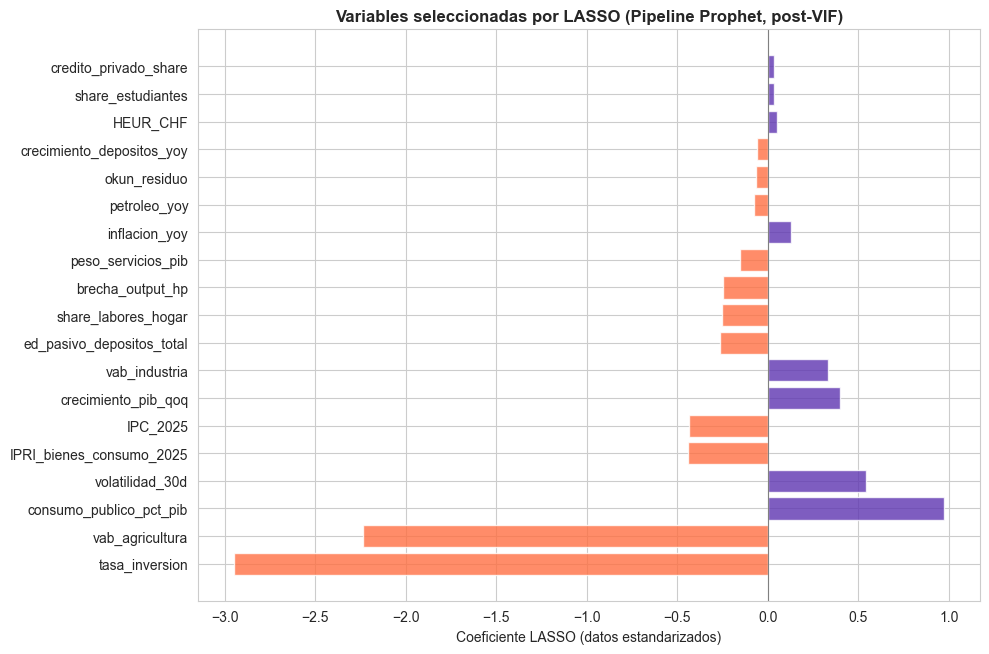

In [29]:
# ── 7.3 LASSO CON VALIDACIÓN CRUZADA TEMPORAL (solo Pipeline Prophet) ────────
# LASSO impone sesgo lineal: descarta features con poder predictivo no lineal.
# Por eso solo se aplica al pipeline Prophet

if target_col in eng.columns and len(vars_post_vif) > 0:
    
    datos_lasso = eng[[target_col] + vars_post_vif].dropna()
    
    X = datos_lasso[vars_post_vif].values
    y_target = datos_lasso[target_col].values
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    tscv = TimeSeriesSplit(n_splits=5)
    
    lasso_cv = LassoCV(
        cv=tscv,
        max_iter=5000,
        random_state=42,
        n_alphas=50,
    )
    lasso_cv.fit(X_scaled, y_target)
    
    coefs_lasso = pd.Series(
        lasso_cv.coef_,
        index=vars_post_vif
    ).sort_values(key=abs, ascending=False)
    
    print(f'LASSO alpha optimo: {lasso_cv.alpha_:.6f}')
    print(f'Variables con coeficiente != 0: {(coefs_lasso != 0).sum()} de {len(vars_post_vif)}')
    
    coefs_no_cero = coefs_lasso[coefs_lasso != 0]
    if len(coefs_no_cero) > 0:
        fig, ax = plt.subplots(figsize=(10, max(4, len(coefs_no_cero) * 0.35)))
        colores_lasso = ['#5E35B1' if v >= 0 else '#FF7043' for v in coefs_no_cero.values]
        ax.barh(coefs_no_cero.index, coefs_no_cero.values, color=colores_lasso, alpha=0.8)
        ax.axvline(0, color='gray', lw=0.8)
        ax.set_xlabel('Coeficiente LASSO (datos estandarizados)', fontsize=10)
        ax.set_title('Variables seleccionadas por LASSO (Pipeline Prophet, post-VIF)',
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    df_lasso = coefs_lasso.reset_index()
    df_lasso.columns = ['variable', 'lasso_coef']
else:
    df_lasso = pd.DataFrame()

El Lasso retiene 19 de las 51 candidatas con un alpha óptimo de 0.168, un resultado muy distinto del que producía el panel sin depurar. Antes de descartar las variables redundantes, la colinealidad extrema forzaba un alpha alto y dejaba el modelo degenerado en apenas tres coeficientes; una vez eliminadas las combinaciones exactas, la ruta de regularización se estabiliza y el Lasso discrimina de forma útil. Es la confirmación de que depurar la multicolinealidad no solo es una exigencia estructural, también mejora la capacidad selectiva del propio método.

Los dos coeficientes dominantes son `tasa_inversion` (-2.95) y `vab_agricultura` (-2.26), seguidos a distancia por `consumo_publico_pct_pib`, `volatilidad_30d`, `IPRI_bienes_consumo` y `crecimiento_pib_qoq`. La señal cíclica esperada aparece, con el crecimiento del PIB y la brecha de producción entre los seleccionados, pero conviene marcar las dos cabezas de lista: el peso de `vab_agricultura` ya se identificó como bandera amarilla por su dominio sospechoso, y `tasa_inversion`, pese a encabezar el Lasso, es uno de los casos de estacionariedad ambigua del panel. Ambas exigen validación fuera de muestra antes de elevarlas a regresor estructural, porque el Lasso ordena por ajuste en muestra, no por robustez predictiva.

In [30]:
# ── 7.4a TABLA DE RECOMENDACIÓN: PIPELINE A (Prophet) ───────────────────────

if len(df_granger) > 0 and len(df_lasso) > 0:
    
    # Filtrar Granger a variables post-VIF
    tabla_prophet = df_granger[df_granger['variable'].isin(vars_post_vif)][
        ['variable', 'granger_p_min', 'granger_lag_opt', 'granger_sig_10pct']
    ].copy()
    
    if len(df_lag_max) > 0:
        tabla_prophet = tabla_prophet.merge(
            df_lag_max.reset_index().rename(columns={'index': 'variable'}),
            on='variable', how='left'
        )
    
    tabla_prophet = tabla_prophet.merge(df_lasso, on='variable', how='left')
    tabla_prophet['lasso_selecciona'] = tabla_prophet['lasso_coef'] != 0
    tabla_prophet['RECOMENDADA'] = tabla_prophet['granger_sig_10pct'] | tabla_prophet['lasso_selecciona']
    tabla_prophet = tabla_prophet.sort_values('granger_p_min')
    
    print('=' * 90)
    print('PIPELINE A — PROPHET: TABLA DE RECOMENDACION')
    print('Criterio automatico: Granger sig. al 10% OR LASSO coef != 0')
    print('Revision semi-manual requerida antes de definir vars_prophet')
    print('=' * 90)
    display(tabla_prophet.set_index('variable'))
    
    vars_recomendadas_prophet = tabla_prophet[tabla_prophet['RECOMENDADA']]['variable'].tolist()
    print(f'\nVariables recomendadas Prophet ({len(vars_recomendadas_prophet)}):')
    print(vars_recomendadas_prophet)
    
else:
    print('Tabla Prophet no disponible: completar bloques 7.1-7.3 primero')
    vars_recomendadas_prophet = vars_post_vif

PIPELINE A — PROPHET: TABLA DE RECOMENDACION
Criterio automatico: Granger sig. al 10% OR LASSO coef != 0
Revision semi-manual requerida antes de definir vars_prophet


,granger_p_min,granger_lag_opt,granger_sig_10pct,lag_max_corr_abs,lasso_coef,lasso_selecciona,RECOMENDADA
variable,,,,,,,
share_labores_hogar,0.000,3,True,8,-0.252,True,True
crecimiento_pib_qoq,0.000,3,True,7,0.400,True,True
brecha_genero_empleo,0.000,1,True,-8,0.000,False,True
share_estudiantes,0.000,3,True,8,0.036,True,True
crecimiento_pib_yoy,0.000,1,True,8,0.000,False,True
peso_servicios_pib,0.000,4,True,-5,-0.155,True,True
peso_construccion_pib,0.000,4,True,7,0.000,False,True
brecha_output_hp,0.000,5,True,-1,-0.244,True,True
IPC_2025,0.000,4,True,-8,-0.434,True,True



Variables recomendadas Prophet (47):
['share_labores_hogar', 'crecimiento_pib_qoq', 'brecha_genero_empleo', 'share_estudiantes', 'crecimiento_pib_yoy', 'peso_servicios_pib', 'peso_construccion_pib', 'brecha_output_hp', 'IPC_2025', 'ipi_constantes_2025_bienes_intermedios', 'ipi_constantes_2025_total_industria', 'IPRI_bienes_consumo_2025', 'IPRI_bienes_intermedios_2025', 'IPRI_total_industria_2025', 'ipi_constantes_2025_bienes_equipo', 'apertura_comercial', 'saldo_comercial_pct_pib', 'consumo_publico_pct_pib', 'fbcf', 'ed_pasivo_sector_privado_share', 'vab_construccion', 'vab_agricultura', 'tasa_inversion', 'consumo_privado_nacional', 'consumo_publico', 'credito_privado_share', 'vab_industria', 'precio_petroleo_real2025', 'importacion_bienes_servicios', 'crecimiento_credito_yoy', 'share_empleo_publico', 'tasa_autoempleo', 'exportacion_bienes_servicios', 'petroleo__volatilidad_30d', 'ratio_asalariados', 'crecimiento_depositos_yoy', 'petroleo_yoy', 'inflacion_qoq', 'HEUR_USD', 'okun_resid

In [31]:
# ── 7.4b TABLA DE RECOMENDACIÓN: PIPELINE B (Árboles: XGBoost + RF) ─────────

if len(df_granger) > 0:
    
    # Todas las variables candidatas (sin filtro VIF)
    tabla_trees = df_granger[
        ['variable', 'granger_p_min', 'granger_lag_opt', 'granger_sig_20pct']
    ].copy()
    
    if len(df_lag_max) > 0:
        tabla_trees = tabla_trees.merge(
            df_lag_max.reset_index().rename(columns={'index': 'variable'}),
            on='variable', how='left'
        )
    
    # Criterio Trees: Granger al 20% OR cross-correlación |r| > 0.2 en algun lag
    if len(corr_lags) > 0:
        max_abs_corr = corr_lags.abs().max(axis=1)
        tabla_trees = tabla_trees.merge(
            max_abs_corr.reset_index().rename(columns={'index': 'variable', 0: 'max_abs_xcorr'}),
            on='variable', how='left'
        )
        tabla_trees['xcorr_relevante'] = tabla_trees['max_abs_xcorr'] > 0.2
    else:
        tabla_trees['max_abs_xcorr'] = np.nan
        tabla_trees['xcorr_relevante'] = False
    
    tabla_trees['RECOMENDADA'] = tabla_trees['granger_sig_20pct'] | tabla_trees['xcorr_relevante']
    tabla_trees = tabla_trees.sort_values('granger_p_min')
    
    print('=' * 90)
    print('PIPELINE B — ÁRBOLES: TABLA DE RECOMENDACION')
    print('Criterio automatico: Granger sig. al 20% OR cross-correlacion |r| > 0.2')
    print('Sin VIF, sin LASSO (interpretabilidad post-modelado con SHAP)')
    print('Revision semi-manual requerida antes de definir vars_trees')
    print('=' * 90)
    display(tabla_trees.set_index('variable'))
    
    vars_recomendadas_trees = tabla_trees[tabla_trees['RECOMENDADA']]['variable'].tolist()
    print(f'\nVariables recomendadas Árboles ({len(vars_recomendadas_trees)}):')
    print(vars_recomendadas_trees)
    
else:
    print('Tabla Trees no disponible: completar bloque 7.1 primero')
    vars_recomendadas_trees = vars_candidatas_mc

PIPELINE B — ÁRBOLES: TABLA DE RECOMENDACION
Criterio automatico: Granger sig. al 20% OR cross-correlacion |r| > 0.2
Sin VIF, sin LASSO (interpretabilidad post-modelado con SHAP)
Revision semi-manual requerida antes de definir vars_trees


,granger_p_min,granger_lag_opt,granger_sig_20pct,lag_max_corr_abs,max_abs_xcorr,xcorr_relevante,RECOMENDADA
variable,,,,,,,
share_labores_hogar,0.000,3,True,8,0.085,False,True
crecimiento_pib_qoq,0.000,3,True,7,0.096,False,True
brecha_genero_empleo,0.000,1,True,-8,0.601,True,True
share_estudiantes,0.000,3,True,8,0.041,False,True
crecimiento_pib_yoy,0.000,1,True,8,0.339,True,True
peso_servicios_pib,0.000,4,True,-5,0.111,False,True
peso_construccion_pib,0.000,4,True,7,0.162,False,True
brecha_output_hp,0.000,5,True,-1,0.198,False,True
IPC_2025,0.000,4,True,-8,0.167,False,True



Variables recomendadas Árboles (53):
['share_labores_hogar', 'crecimiento_pib_qoq', 'brecha_genero_empleo', 'share_estudiantes', 'crecimiento_pib_yoy', 'peso_servicios_pib', 'peso_construccion_pib', 'brecha_output_hp', 'IPC_2025', 'ipi_constantes_2025_bienes_intermedios', 'prima_energia', 'ipi_constantes_2025_total_industria', 'IPRI_bienes_consumo_2025', 'IPRI_bienes_intermedios_2025', 'IPRI_energia_2025', 'IPRI_total_industria_2025', 'ipi_constantes_2025_bienes_equipo', 'apertura_comercial', 'saldo_comercial_pct_pib', 'consumo_publico_pct_pib', 'fbcf', 'ed_pasivo_sector_privado_share', 'vab_construccion', 'vab_agricultura', 'tasa_inversion', 'consumo_privado_nacional', 'consumo_publico', 'credito_privado_share', 'vab_industria', 'precio_petroleo_real2025', 'importacion_bienes_servicios', 'crecimiento_credito_yoy', 'share_empleo_publico', 'spread_gbp_usd', 'tasa_autoempleo', 'exportacion_bienes_servicios', 'petroleo__volatilidad_30d', 'ratio_asalariados', 'crecimiento_depositos_yoy', 

In [ ]:
# -- 7.4c LISTAS DE SELECCIÓN RECOMENDADAS (mapa exploratorio) ----------------
# Cristaliza las recomendaciones de 7.4a y 7.4b en una lista por pipeline. Es el mapa
# exploratorio sobre todo el histórico, no la selección vinculante: la selección definitiva de
# cada modelo se decide embebida en cada fold del expanding window en los notebooks de modelado.

vars_prophet = vars_recomendadas_prophet.copy()
vars_trees   = vars_recomendadas_trees.copy()

print('SELECCIÓN RECOMENDADA (mapa exploratorio, no vinculante):')
print(f'  Prophet: {len(vars_prophet)} variables')
print(f'  Árboles: {len(vars_trees)} variables')
print(f'  vars_prophet ⊆ vars_trees: {set(vars_prophet).issubset(set(vars_trees))}')

print(f'\nProphet: {vars_prophet}')
print(f'\nArboles: {vars_trees}')

solo_trees = set(vars_trees) - set(vars_prophet)
if solo_trees:
    print(f'\nSolo en árboles (la vista lineal las descarta por colinealidad): {sorted(solo_trees)}')


El mapa exploratorio recomienda 47 regresores para Prophet y 53 para árboles, con el conjunto de Prophet contenido en el de árboles. La diferencia entre ambos refleja la arquitectura del panel: Prophet, aditivo y sensible a la colinealidad, parte del conjunto ya depurado de redundancias, mientras que los árboles conservan casi todas las candidatas porque toleran la colinealidad y la interpretan después con SHAP. Los regresores que solo entran en la vista de árboles son precisamente las variables redundantes que el VIF apartó de la lineal.

Conviene subrayar el estatuto de estas listas: son un mapa narrativo sobre todo el histórico, no la selección definitiva. La selección vinculante de cada modelo va embebida dentro de cada pliegue del expanding window, ajustada solo con el tramo de entrenamiento para no filtrar información del futuro. Por eso el conjunto que se exporta a los notebooks de modelado es el panel candidato completo y no estas listas, que sirven para documentar qué variables guardan relación con el paro en el conjunto del periodo y para orientar el criterio económico, no para fijar el modelo final.

## 8. Lags, dummies/changepoints y exports por familia

Desde las dos formas maestras (`panel_estacionario` = candidatas estacionarias + target; `panel_nivel` = target + subconjunto I(1) para VECM) se materializan los **datasets por familia y por canal**. La selección de la sección 7 es el **mapa exploratorio** (ordena); la **selección vinculante embebida en el expanding window** se hace en los notebooks de modelado. Aquí se construyen la matriz de lags (solo para los modelos sin memoria), la dummy 2020-Q2 (control de shock pasado) y los changepoints de Prophet, y se exportan los datasets.

In [33]:
# -- 8. EXPORTS POR FAMILIA Y POR CANAL + LAGS + DUMMIES/CHANGEPOINTS ----------
# Los datasets de modelado se guardan en la carpeta 'Datasets Modelado/', separados de las series
# fuente. Nombre: <grupo>_<forma>_modelado (el sufijo _modelado los localiza en una busqueda).
# Formas: nivel (Prophet/VECM) | estacionario (econométricos/canales) | estacionario_lags (ML).
target_col = 'tasa_paro_total'
RUTA_MODELADO = RUTA_BASE.parent / 'Datasets Modelado'
RUTA_MODELADO.mkdir(exist_ok=True)

# --- 8.1 Dummy 2020-Q2 (control de shock PASADO) + changepoints (Prophet) ---
DUMMY_EVENTOS = ['2020-04-01', '2020-07-01']                      # 2020-Q2 + rebote Q3
CHANGEPOINTS  = ['1985-01-01', '1994-01-01', '2008-01-01', '2013-01-01', '2020-01-01']
dummy_2020 = pd.Series(0, index=panel_estacionario.index, name='dummy_2020Q2')
for f in DUMMY_EVENTOS:
    ts = pd.Timestamp(f)
    if ts in dummy_2020.index:
        dummy_2020.loc[ts] = 1
print(f'Dummy 2020-Q2: {int(dummy_2020.sum())} trim | Changepoints: {CHANGEPOINTS}')

# --- 8.2 Selección exploratoria (informativa). Se exporta el conjunto candidato completo; la
#         selección final de variables se decide en los notebooks de modelado (validación cruzada). ---
_todas = [c for c in panel_estacionario.columns if c != target_col]
try:    map_prophet = [v for v in vars_prophet if v in panel_estacionario.columns]
except NameError: map_prophet = _todas
try:    map_trees = [v for v in vars_trees if v in panel_estacionario.columns]
except NameError: map_trees = _todas
sel_prophet = _todas   # editar para forzar un subconjunto; la selección final se hace en modelado
sel_trees   = _todas
print(f'Candidatas exportadas (conjunto completo): {len(_todas)} | selección exploratoria -> Prophet {len(map_prophet)}, Árboles {len(map_trees)}')

# --- 8.3 Matriz de lags por lógica de negocio (solo modelos sin memoria: árboles, Ridge, Lasso) ---
def lags_de(nombre):
    if any(k in nombre.lower() for k in ['credito', 'activo', 'pasivo', 'deposito', 'banca']):
        return range(1, 9)     # ciclo de crédito largo
    return range(1, 5)

def con_lags(df_base, columnas):
    out = pd.DataFrame(index=df_base.index)
    for c in columnas:
        out[c] = df_base[c]
        for L in lags_de(c):
            out[f'{c}_lag{L}'] = df_base[c].shift(L)
    return out

# --- 8.4 Canales económicos (subpaneles auxiliares; Stock & Watson). Listas exactas y disjuntas
#         (MECE): cada regresor pertenece a un solo canal, para que un modelo por canal o un PCA por
#         canal no cuente la misma variable dos veces. ---
CANALES = {
    'laboral':       ['ratio_asalariados', 'share_empleo_publico', 'tasa_autoempleo',
                      'share_labores_hogar', 'share_estudiantes', 'brecha_genero_empleo'],
    'precios':       ['IPC_2025', 'inflacion_yoy', 'inflacion_qoq', 'IPRI_total_industria_2025',
                      'IPRI_bienes_intermedios_2025', 'IPRI_bienes_consumo_2025', 'ipri_yoy'],
    'energia':       ['precio_petroleo_real2025', 'petroleo_yoy', 'petroleo__volatilidad_30d',
                      'IPRI_energia_2025', 'prima_energia'],
    'industrial':    ['ipi_constantes_2025_total_industria', 'ipi_constantes_2025_bienes_equipo',
                      'ipi_constantes_2025_bienes_intermedios'],
    'macro':         ['crecimiento_pib_qoq', 'crecimiento_pib_yoy', 'brecha_output_hp', 'okun_residuo',
                      'peso_construccion_pib', 'peso_servicios_pib', 'fbcf', 'consumo_privado_nacional',
                      'consumo_publico', 'exportacion_bienes_servicios', 'importacion_bienes_servicios',
                      'tasa_inversion', 'apertura_comercial', 'saldo_comercial_pct_pib',
                      'consumo_publico_pct_pib', 'vab_industria', 'vab_construccion', 'vab_agricultura'],
    'cambiario':     ['tipo_interes_real', 'HEUR_USD', 'HEUR_GBP', 'HEUR_CHF', 'heur_usd_yoy_pct',
                      'volatilidad_30d', 'spread_gbp_usd', 'interes_legal', 'diferencial', 'cambio_tipo'],
    'credito_banca': ['ed_activo_total', 'credito_privado_share', 'crecimiento_credito_yoy',
                      'ed_pasivo_depositos_total', 'crecimiento_depositos_yoy',
                      'ed_pasivo_sector_privado_share'],
}

# Verificación MECE: cada regresor del panel debe estar en exactamente un canal
_reg = [c for c in panel_estacionario.columns if c != target_col]
_asig = [c for cs in CANALES.values() for c in cs]
_sin_canal = sorted(set(_reg) - set(_asig))
_fantasma  = sorted(set(_asig) - set(_reg))
_repetidas = sorted({c for c in _asig if _asig.count(c) > 1})
print(f'Canales: {len(CANALES)} | regresores asignados: {len(_asig)}/{len(_reg)}')
if _sin_canal: print(f'  sin canal: {_sin_canal}')
if _fantasma:  print(f'  en CANALES pero no en panel: {_fantasma}')
if _repetidas: print(f'  en mas de un canal: {_repetidas}')

def cols_canal(cols):
    return [c for c in cols if c in panel_estacionario.columns]

# --- 8.5 Construir y guardar los datasets de modelado ---
EXPORTS = {}
# Familias
prophet_df = pd.DataFrame(index=panel_estacionario.index)
prophet_df['y'] = panel_estacionario[target_col]
for c in sel_prophet: prophet_df[c] = panel_estacionario[c]
prophet_df['dummy_2020Q2'] = dummy_2020
EXPORTS['prophet_nivel_modelado'] = prophet_df

EXPORTS['vecm_nivel_modelado'] = panel_nivel.copy()

econ_df = panel_estacionario[[target_col] + sel_prophet].copy()
econ_df['dummy_2020Q2'] = dummy_2020
EXPORTS['econometricos_estacionario_modelado'] = econ_df

ml_df = con_lags(panel_estacionario, sel_trees)
ml_df.insert(0, target_col, panel_estacionario[target_col])
ml_df['dummy_2020Q2'] = dummy_2020
EXPORTS['ml_estacionario_lags_modelado'] = ml_df

# Canales (auxiliares): forma estacionaria + target + dummy
for canal, cols in CANALES.items():
    cc = cols_canal(cols)
    if cc:
        cdf = panel_estacionario[[target_col] + cc].copy()
        cdf['dummy_2020Q2'] = dummy_2020
        EXPORTS[f'canal_{canal}_estacionario_modelado'] = cdf

print('\nDATASETS DE MODELADO (carpeta Datasets Modelado/):')
for nombre, df in EXPORTS.items():
    df.to_csv(RUTA_MODELADO / f'{nombre}.csv')
    print(f'  {nombre}.csv  ->  {df.shape[1]} cols, {len(df)} obs')

print('\nReferencias editables: CANDIDATOS_MACRO y VECM_NIVELES (bloque 5.2),')
print('sel_prophet/sel_trees, DUMMY_EVENTOS, CHANGEPOINTS, lags_de(), CANALES (bloque 8).')
print('La selección final de variables se hace en los notebooks de modelado (validacion cruzada temporal).')

Dummy 2020-Q2: 2 trim | Changepoints: ['1985-01-01', '1994-01-01', '2008-01-01', '2013-01-01', '2020-01-01']
Candidatas exportadas (conjunto completo): 55 | selección exploratoria -> Prophet 47, Árboles 53
Canales: 7 | regresores asignados: 55/55

DATASETS DE MODELADO (carpeta Datasets Modelado/):
  prophet_nivel_modelado.csv  ->  57 cols, 198 obs
  vecm_nivel_modelado.csv  ->  3 cols, 198 obs
  econometricos_estacionario_modelado.csv  ->  57 cols, 198 obs
  ml_estacionario_lags_modelado.csv  ->  301 cols, 198 obs
  canal_laboral_estacionario_modelado.csv  ->  8 cols, 198 obs
  canal_precios_estacionario_modelado.csv  ->  9 cols, 198 obs
  canal_energia_estacionario_modelado.csv  ->  7 cols, 198 obs
  canal_industrial_estacionario_modelado.csv  ->  5 cols, 198 obs
  canal_macro_estacionario_modelado.csv  ->  20 cols, 198 obs
  canal_cambiario_estacionario_modelado.csv  ->  12 cols, 198 obs
  canal_credito_banca_estacionario_modelado.csv  ->  8 cols, 198 obs

Referencias editables: CAND

### 8.6 Decisiones de exportación y limitaciones

Los datasets de modelado materializan las decisiones anteriores en cuatro vistas por familia y siete por canal, en la carpeta `Datasets Modelado/`.

**Rezagos.** Se distinguen dos. El rezago de disponibilidad (`lag_pub`), aplicado en la sección 4.6, alinea cada regresor al trimestre en que su dato está publicado y es común a todas las vistas. El rezago de negocio, la matriz de columnas `var_lag1` a `var_lagN` (1 a 4 trimestres, y hasta 8 para el ciclo de crédito y depósitos), se fabrica solo para la vista de árboles y modelos lineales, porque carecen de memoria propia; Prophet, ARIMA, SARIMAX y VECM incorporan sus rezagos por su estructura (componentes aditivos, órdenes AR y MA, orden del sistema) y no la necesitan.

**Dummy y rupturas.** La única dummy activa es 2020-Q2, como control del shock pasado de la COVID, nunca como columna estática que revele el punto de test. Las rupturas de régimen (1985, 1994, 2008, 2013, 2020) se tratan como changepoints de Prophet, no como dummies, por ser cambios de pendiente de la tendencia y no pulsos puntuales.

**Canales.** Los siete subpaneles por canal son disjuntos, cada regresor en uno solo, lo que permite un modelo o una extracción de factores por canal sin doble conteo.

**Limitación y vía de mejora: datos vintage.** El panel usa la serie final revisada de cada variable, no el dato tal como se publicó en su momento. Un vintage es esa fotografía: el valor de un indicador conocido en una fecha dada, antes de revisiones posteriores. Una base de datos de vintages, o real-time database, guardaría para cada trimestre histórico la secuencia de estimaciones, desde el primer dato hasta su revisión final. Disponer de ella permitiría backtestear con el dato que de verdad se conocía en cada momento, eliminando el sesgo optimista de usar el revisado y capturando la incertidumbre de las primeras estimaciones, especialmente del PIB. No se dispone de esa base en este trabajo, por lo que queda como vía de enriquecimiento futuro y no como un defecto del modelo.

**Indicadores en tiempo real.** Como el PIB se mide con retardo, el nowcast se apoya en los indicadores de publicación inmediata, petróleo, tipo de cambio e IPC, que aproximan la actividad del trimestre en curso: la empresa conoce su propia situación en tiempo real aunque la estadística agregada llegue después, de modo que esos indicadores capturan la señal contemporánea que el PIB publicado no da a tiempo.